# Wildberries shipment forecasting — EDA rehearsal

Цель: воспроизводимая репетиция EDA для вступительного испытания. Все числа, проверки и графики ниже вычисляются из parquet-файлов кодом из `eda_exam_rehearsal.py`.

Правила первого прохода:

- raw-данные не изменяются;
- строки не удаляются;
- значения не заполняются и не обрезаются;
- выбросы пока только описываются;
- корреляции считаются описательными связями, а не причинными эффектами;
- решения об очистке, split, признаках и моделях принимаются отдельно после аудита.

## 0. Вопросы, на которые отвечает raw-data audit

1. Какие файлы получены и можем ли мы воспроизвести их идентичность?
2. Какова единица наблюдения и уникален ли кандидатный ключ?
3. Полна и регулярна ли временная сетка?
4. Совпадают ли маршруты train и test?
5. Как устроен горизонт прогноза?
6. Есть ли пропуски, дубли, отрицательные и нулевые значения?
7. Насколько неоднородны target и маршруты?
8. Какие временные паттерны видны без преобразования данных?
9. Какие связи и автокорреляции требуют дальнейшей проверки?
10. Какие методологические решения нельзя принимать автоматически?

In [1]:
from time import perf_counter

import pandas as pd
from IPython.display import Image, Markdown, display

from eda_exam_rehearsal import ARTIFACT_DIR, PLOT_DIR, run_deep_audit, run_raw_audit
from solution_audit import PLOT_DIR as AUDIT_PLOT_DIR
from solution_audit import run_solution_audit

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.6g}')

started = perf_counter()
audit = run_raw_audit()
elapsed = perf_counter() - started
bundle = audit['bundle']
tables = audit['tables']
print(f'Raw audit completed in {elapsed:.2f} seconds')
print(f'Train shape: {bundle.train.shape}; test shape: {bundle.test.shape}')
print(f'Artifacts: {ARTIFACT_DIR}')

Raw audit completed in 7.16 seconds
Train shape: (4630000, 9); test shape: (8000, 3)
Artifacts: ./artifacts/eda_exam


## 1. Происхождение и неизменность файлов

SHA-256 нужен, чтобы доказать, что анализ повторно запущен на тех же входных файлах. Размеры и число строк берутся из parquet metadata.

In [2]:
display(tables['manifest'])
display(Markdown(
    f"**Зафиксировано кодом:** rows dropped = {audit['metadata']['rows_dropped']}, "
    f"values clipped = {audit['metadata']['values_clipped']}, "
    f"values imputed = {audit['metadata']['values_imputed']}."
))

,file,bytes,size_mib,rows,columns,row_groups,sha256
0,train_solo_track.parquet,94465651,90.0895,4630000,9,5,300aecbe2d3dc28be03bff957ba56ab20c7fa8ceb81b03...
1,test_solo_track.parquet,55000,0.0524521,8000,3,1,62442611ead0ed9eaad187b461c6c6d4584c17016f8276...


**Зафиксировано кодом:** rows dropped = 0, values clipped = 0, values imputed = 0.

## 2. Схема, типы и примеры строк

Просмотр строк используется только для понимания структуры. Статистические выводы по `head()` не делаются.

In [3]:
display(tables['train_overview'])
display(tables['test_overview'])
display(Markdown('**Train: первые и последние три строки после чтения файла**'))
display(pd.concat([bundle.train.head(3), bundle.train.tail(3)]))
display(Markdown('**Test: первые и последние три строки после чтения файла**'))
display(pd.concat([bundle.test.head(3), bundle.test.tail(3)]))

,table,column,dtype,rows,missing_count,missing_pct,unique_including_na,zero_count,negative_count,min,median,max
0,train,route_id,int64,4630000,0,0,1000,"4,630",0,0,499.5,999
1,train,timestamp,datetime64[ns],4630000,0,0,4630,NaN,NaN,2025-07-28 00:00:00,NaN,2025-11-01 10:30:00
2,train,status_1,int64,4630000,0,0,272,"11,447",0,0,21,802
3,train,status_2,int64,4630000,0,0,243,"9,580",0,0,21,522
4,train,status_3,int64,4630000,0,0,260,"357,890",0,0,19,620
5,train,status_4,int64,4630000,0,0,315655,0,0,1390,"109,912",587938
6,train,status_5,int64,4630000,0,0,1463128,0,0,18519,"618,836",3503114
7,train,status_6,int64,4630000,0,0,82051,"4,817",0,0,162,152739
8,train,target_1h,int64,4630000,0,0,692648,"69,841",0,0,"235,769",10831337


,table,column,dtype,rows,missing_count,missing_pct,unique_including_na,zero_count,negative_count,min,median,max
0,test,id,int64,8000,0,0,8000,1,0,0,"3,999.5",7999
1,test,route_id,int64,8000,0,0,1000,8,0,0,499.5,999
2,test,timestamp,datetime64[ns],8000,0,0,8,NaN,NaN,2025-11-01 11:00:00,NaN,2025-11-01 14:30:00


**Train: первые и последние три строки после чтения файла**

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
0,471,2025-07-28 00:00:00,13,23,45,85645,491354,487,88655
1,471,2025-07-28 00:30:00,14,18,1,80049,494754,489,223929
2,471,2025-07-28 01:00:00,8,8,38,82616,490659,487,168519
4629997,422,2025-11-01 09:30:00,11,20,35,93517,827038,104,210163
4629998,422,2025-11-01 10:00:00,17,19,24,101395,814070,104,328012
4629999,422,2025-11-01 10:30:00,16,18,16,104384,807239,106,227390


**Test: первые и последние три строки после чтения файла**

,id,route_id,timestamp
0,0,471,2025-11-01 11:00:00
1,1,471,2025-11-01 11:30:00
2,2,471,2025-11-01 12:00:00
7997,7997,422,2025-11-01 13:30:00
7998,7998,422,2025-11-01 14:00:00
7999,7999,422,2025-11-01 14:30:00


## 3. Пропуски, точные дубли и кандидатные ключи

Кандидатная единица наблюдения проверяется как `(route_id, timestamp)`. Для test отдельно проверяется уникальность `id`.

,check,value
0,train_rows,4630000
1,test_rows,8000
2,train_exact_duplicate_rows,0
3,test_exact_duplicate_rows,0
4,train_duplicate_key_rows,0
5,test_duplicate_key_rows,0
6,train_duplicate_key_values,0
7,test_duplicate_key_values,0
8,test_duplicate_id_rows,0
9,train_route_count,1000


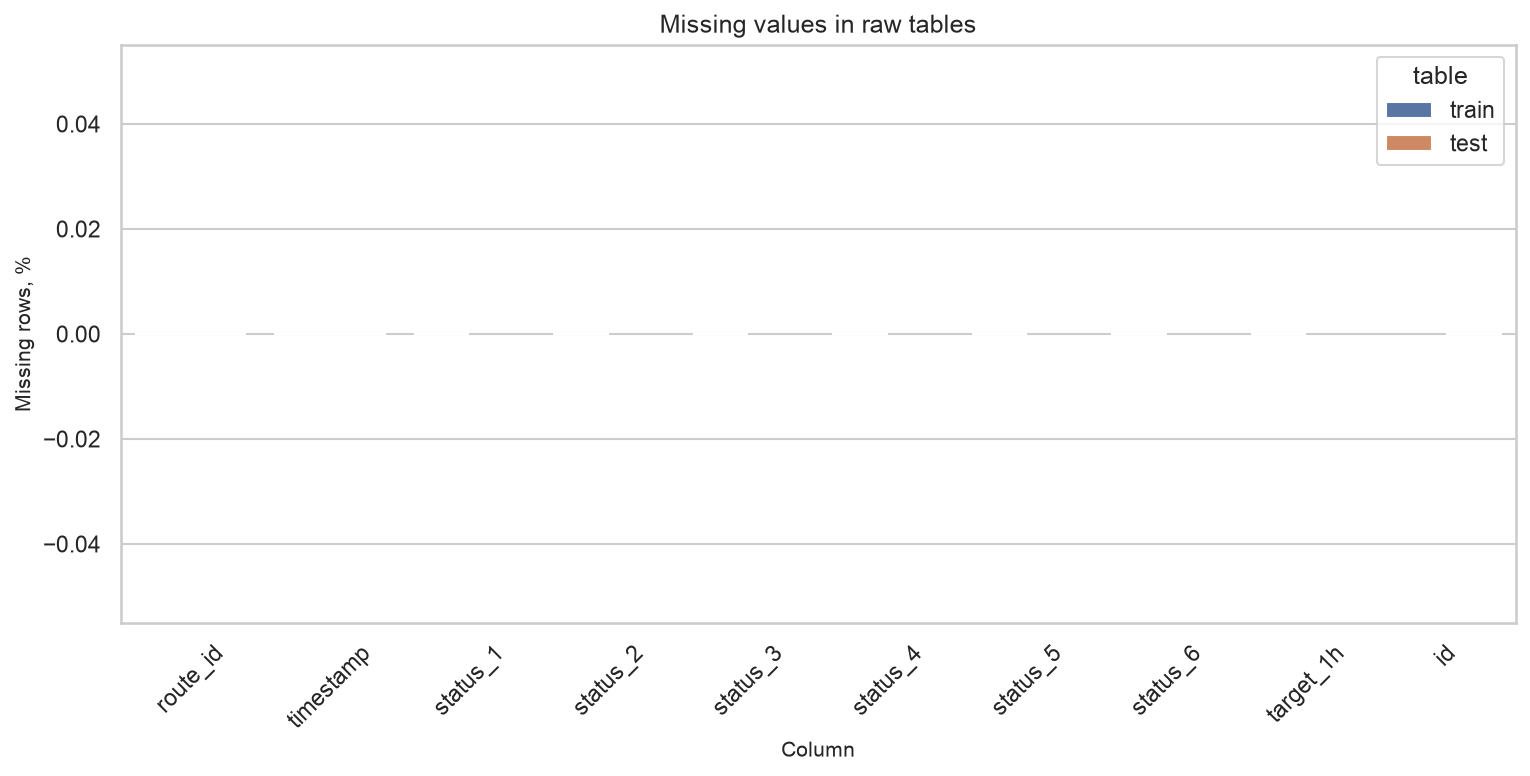

In [4]:
display(tables['key_report'])
display(Image(filename=str(PLOT_DIR / '01_missingness.png')))

## 4. Регулярность временной сетки

Шаг определяется из моды положительных разностей времени внутри маршрута, а не задаётся вручную. Для каждого маршрута код сравнивает наблюдаемое число слотов с ожидаемым числом слотов между его собственными границами.

In [5]:
display(tables['time_overview'])
display(Markdown('**Самые частые интервалы внутри маршрутов**'))
display(tables['delta_counts'].head(20))
display(Markdown('**Распределение полноты сетки по маршрутам**'))
display(tables['route_grid'][['observed_unique_slots', 'expected_slots_between_own_bounds', 'missing_slots_between_own_bounds', 'coverage_pct_between_own_bounds']].describe())

,metric,value
0,modal_positive_step_minutes,30
1,train_min_timestamp,2025-07-28 00:00:00
2,train_max_timestamp,2025-11-01 10:30:00
3,unique_routes,1000
4,unique_route_timestamp_keys,4630000
5,non_modal_positive_transitions,0
6,routes_with_missing_slots_between_own_bounds,0
7,total_missing_slots_between_own_bounds,0
8,routes_with_non_integer_span,0


**Самые частые интервалы внутри маршрутов**

,delta,transition_count,delta_minutes
0,0 days 00:30:00,4629000,30


**Распределение полноты сетки по маршрутам**

,observed_unique_slots,expected_slots_between_own_bounds,missing_slots_between_own_bounds,coverage_pct_between_own_bounds
count,"1,000","1,000","1,000","1,000"
mean,"4,630","4,630",0,100
std,0,0,0,0
min,"4,630","4,630",0,100
25%,"4,630","4,630",0,100
50%,"4,630","4,630",0,100
75%,"4,630","4,630",0,100
max,"4,630","4,630",0,100


## 5. Контракт test и горизонт прогноза

Test связывается с последним timestamp каждого маршрута через `validate='many_to_one'`. Горизонт выражается в шагах, найденных на предыдущем этапе.

,metric,value
0,test_min_timestamp,2025-11-01 11:00:00
1,test_max_timestamp,2025-11-01 14:30:00
2,test_rows,8000
3,test_routes,1000
4,rows_without_train_route,0
5,minimum_rows_per_route,8
6,maximum_rows_per_route,8
7,unique_rows_per_route_values,[8]
8,minimum_horizon_steps,1
9,maximum_horizon_steps,8


,horizon_steps,rows
0,1,1000
1,2,1000
2,3,1000
3,4,1000
4,5,1000
5,6,1000
6,7,1000
7,8,1000


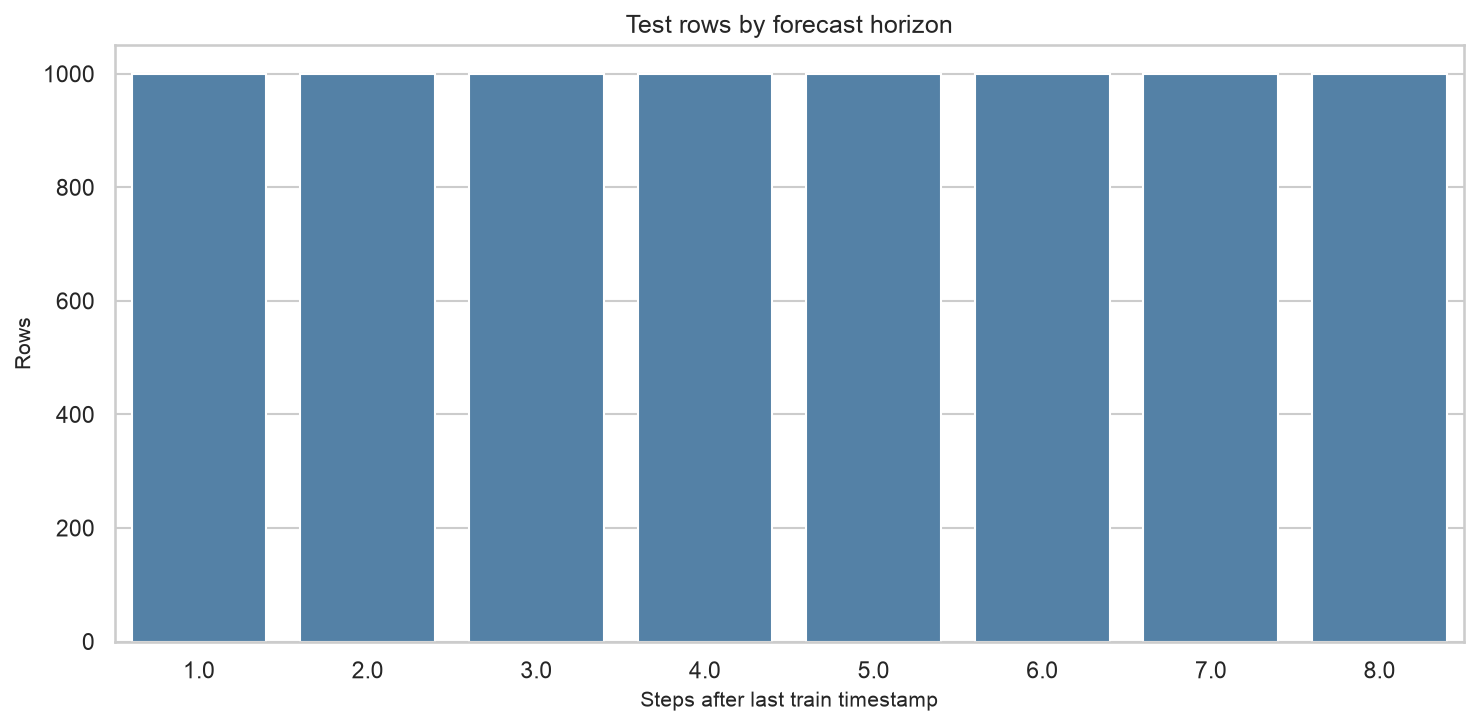

In [6]:
display(tables['horizon_overview'])
display(tables['horizon_counts'])
display(Image(filename=str(PLOT_DIR / '07_test_horizons.png')))

## 6. Распределения числовых столбцов

Таблица содержит точные квантили, долю нулей, отрицательные значения, skewness и kurtosis. Графики используют полный набор строк. `log1p` применяется только к координате графика и не изменяет исходные значения.

,0,1,2,3,4,5,6
column,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
count,4630000,4630000,4630000,4630000,4630000,4630000,4630000
missing,0,0,0,0,0,0,0
mean,22.6768,22.8585,22.8568,"119,216","701,979","3,344.61","261,242"
std,13.0414,12.8578,19.44,"59,825.7","421,306","10,048.2","169,083"
skew,1.253,1.02773,1.19416,0.966419,1.20486,5.20391,2.27878
kurtosis,12.9678,5.77604,2.68728,1.31464,1.91726,32.9951,43.0554
zeros,11447,9580,357890,0,0,4817,69841
zero_pct,0.247235,0.206911,7.72981,0,0,0.104039,1.50844
negatives,0,0,0,0,0,0,0


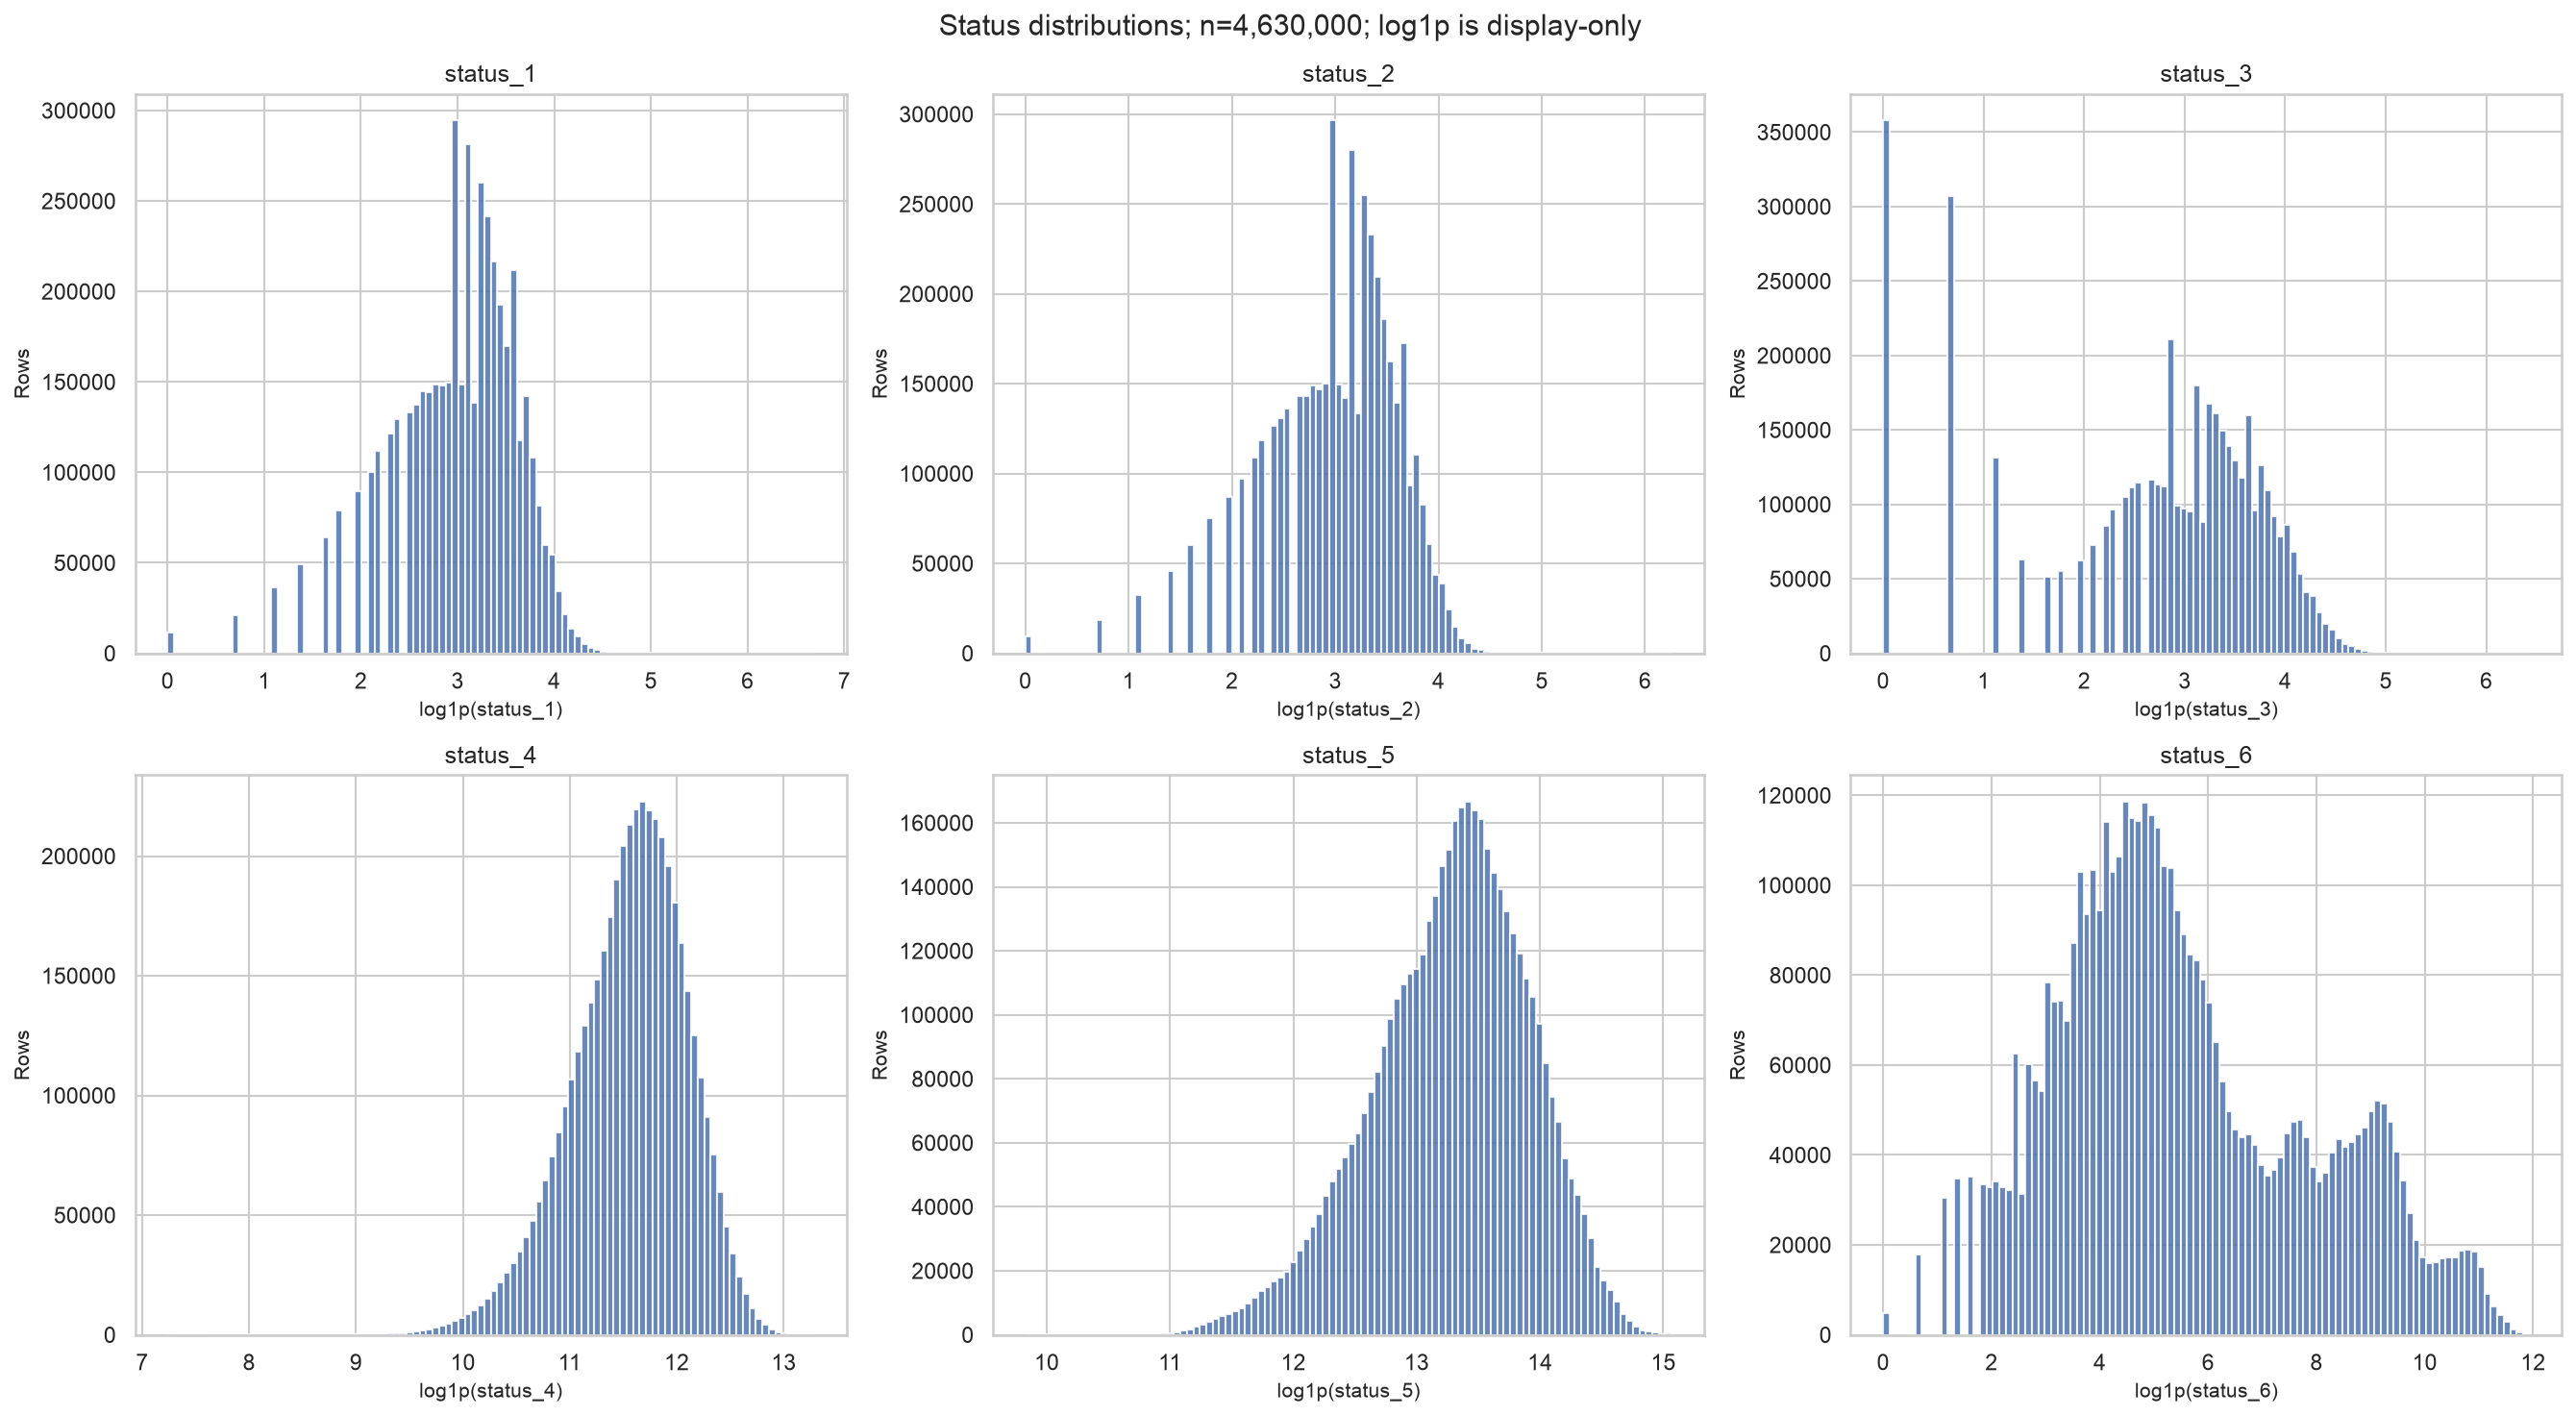

In [7]:
display(tables['numeric_distributions'].T)
display(Image(filename=str(PLOT_DIR / '03_status_distributions.png')))

## 7. Target: центр, хвост, нули и концентрация

Порог Тьюки здесь является только диагностической ссылкой. Строки выше него **не объявляются ошибками** и не удаляются.

,metric,value
0,row_count,4.63e+06
1,total_target,1.20955e+12
2,mean,"261,242"
3,median,"235,769"
4,std,"169,083"
5,minimum,0
6,maximum,1.08313e+07
7,zero_rows,"69,841"
8,zero_pct,1.50844
9,negative_rows,0


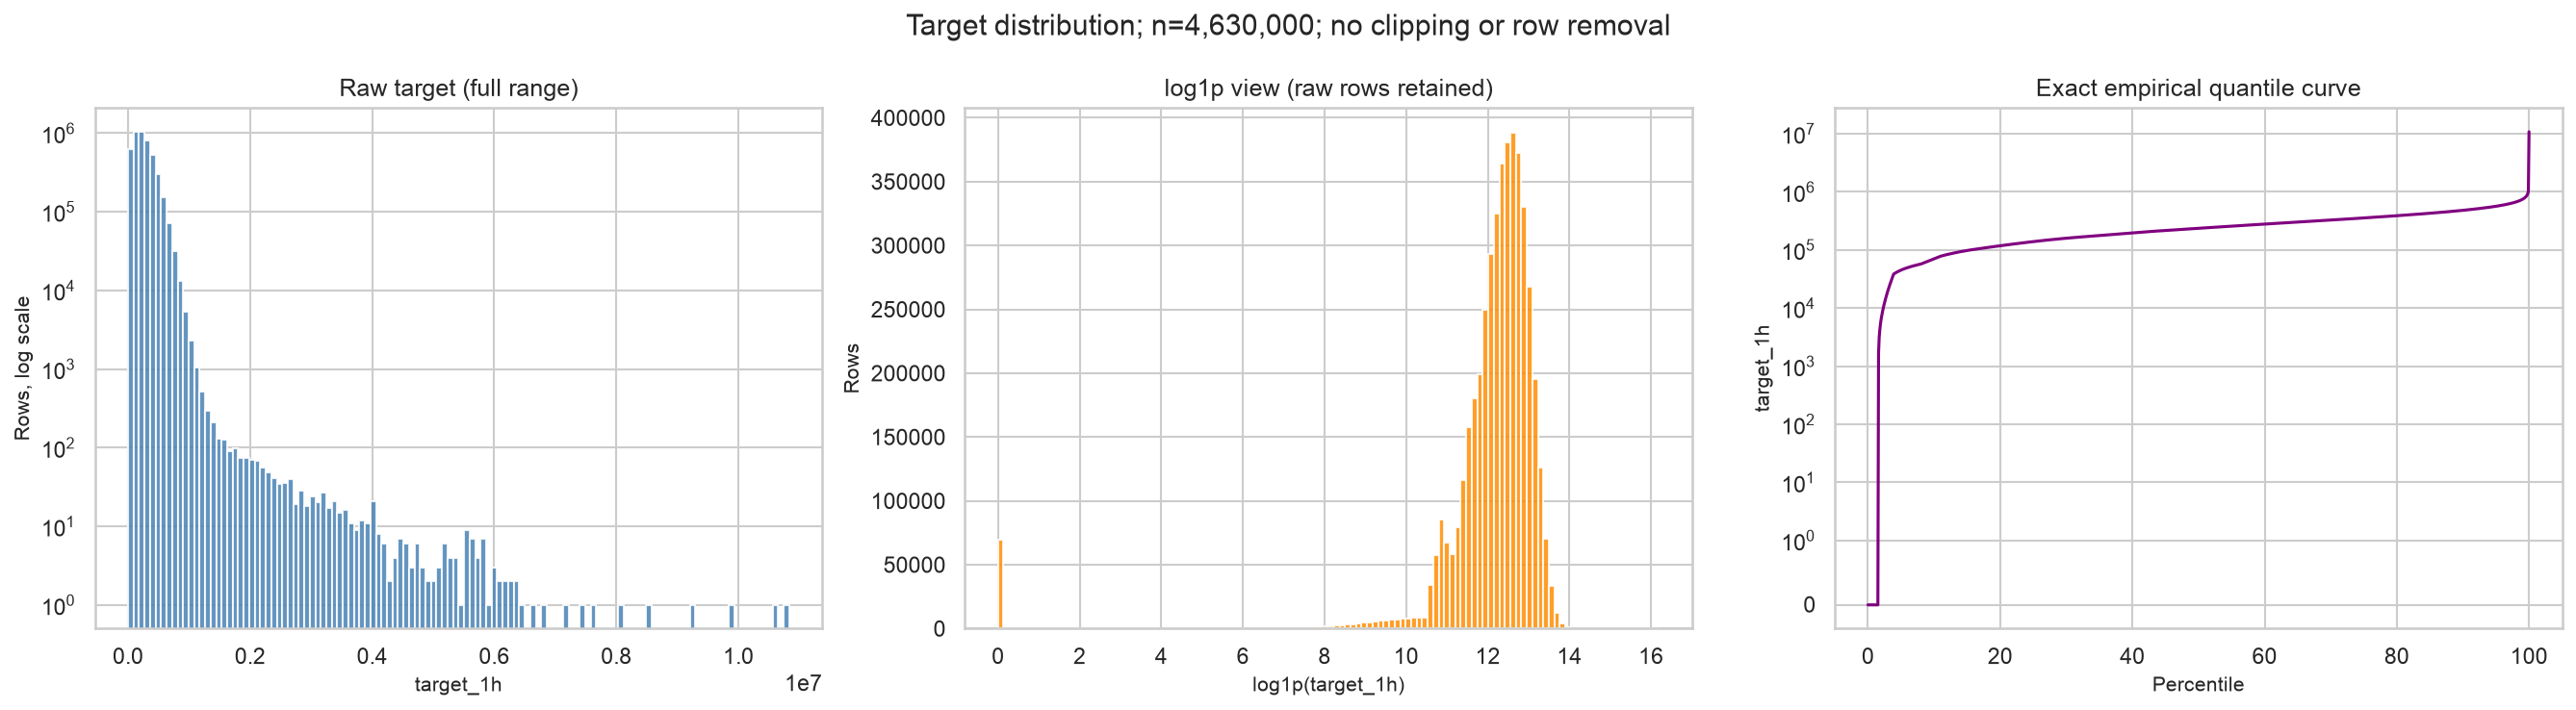

In [8]:
display(tables['target_report'])
display(Image(filename=str(PLOT_DIR / '02_target_distribution.png')))

### Decision checkpoint A — значения target

Перед моделированием нужно совместно решить:

1. Считать ли нули валидным отсутствием отгрузки или возможной технической записью?
2. Считать ли экстремальные значения бизнес-пиками или ошибками?
3. Нужен ли анализ чувствительности метрик с хвостом и без хвоста?
4. Допустима ли трансформация target для обучения с корректным обратным преобразованием?

До ответа raw target сохраняется полностью.

## 8. Неоднородность маршрутов

Сначала каждый маршрут получает равный вес. Затем пять временных рядов выбираются детерминированно по рангам суммарного объёма: минимум, 25%, медиана, 75%, максимум. Последние 14 дней — только фиксированное окно отображения, строки не удаляются из расчётов.

,route_metric,p0,p0_1,p1,p5,p25,p50,p75,p95,p99,p99_9,p100
0,rows,"4,630","4,630","4,630","4,630","4,630","4,630","4,630","4,630","4,630","4,630","4,630"
1,target_sum,2.3498e+08,2.76081e+08,3.37633e+08,4.75111e+08,8.33086e+08,1.19536e+09,1.53437e+09,2.06177e+09,2.36968e+09,2.60471e+09,4.54273e+09
2,target_mean,"50,751.6","59,628.7","72,922.9","102,616","179,932","258,177","331,398","445,306","511,810","562,573","981,152"
3,target_median,"38,855","42,782.1","55,868.9","93,000.3","166,731","246,506","318,904","427,430","495,298","547,880","662,056"
4,target_std,"46,305.9","51,618.7","61,125.5","72,042.9","98,942.2","121,164","144,177","177,003","202,231","564,314","833,103"
5,target_max,"314,787","345,033","398,618","478,428","691,192","860,655",1.07738e+06,1.42739e+06,3.35217e+06,9.84905e+06,1.08313e+07
6,zero_target_pct,0,0,0,0,0.0431965,0.215983,1.46868,7.2797,16.1445,22.7003,23.2397
7,target_share,0.00019427,0.000228251,0.000279139,0.000392799,0.000688756,0.000988265,0.00126855,0.00170457,0.00195914,0.00215345,0.00375572


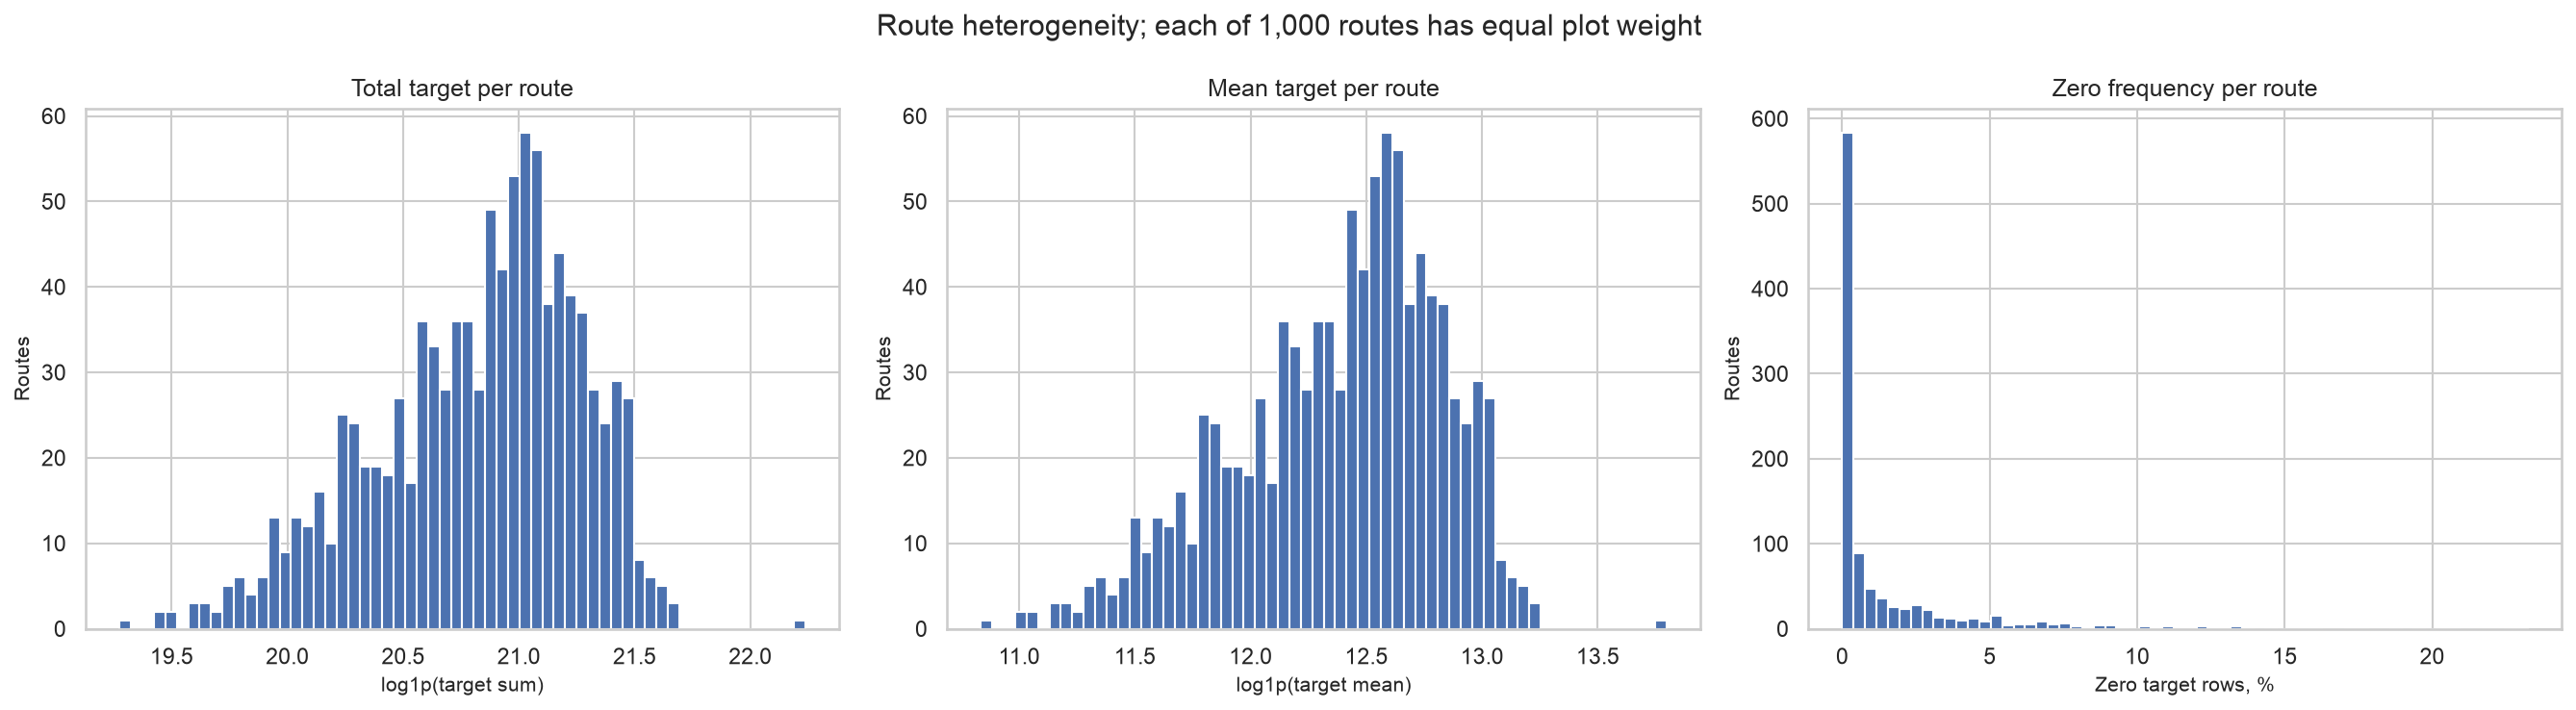

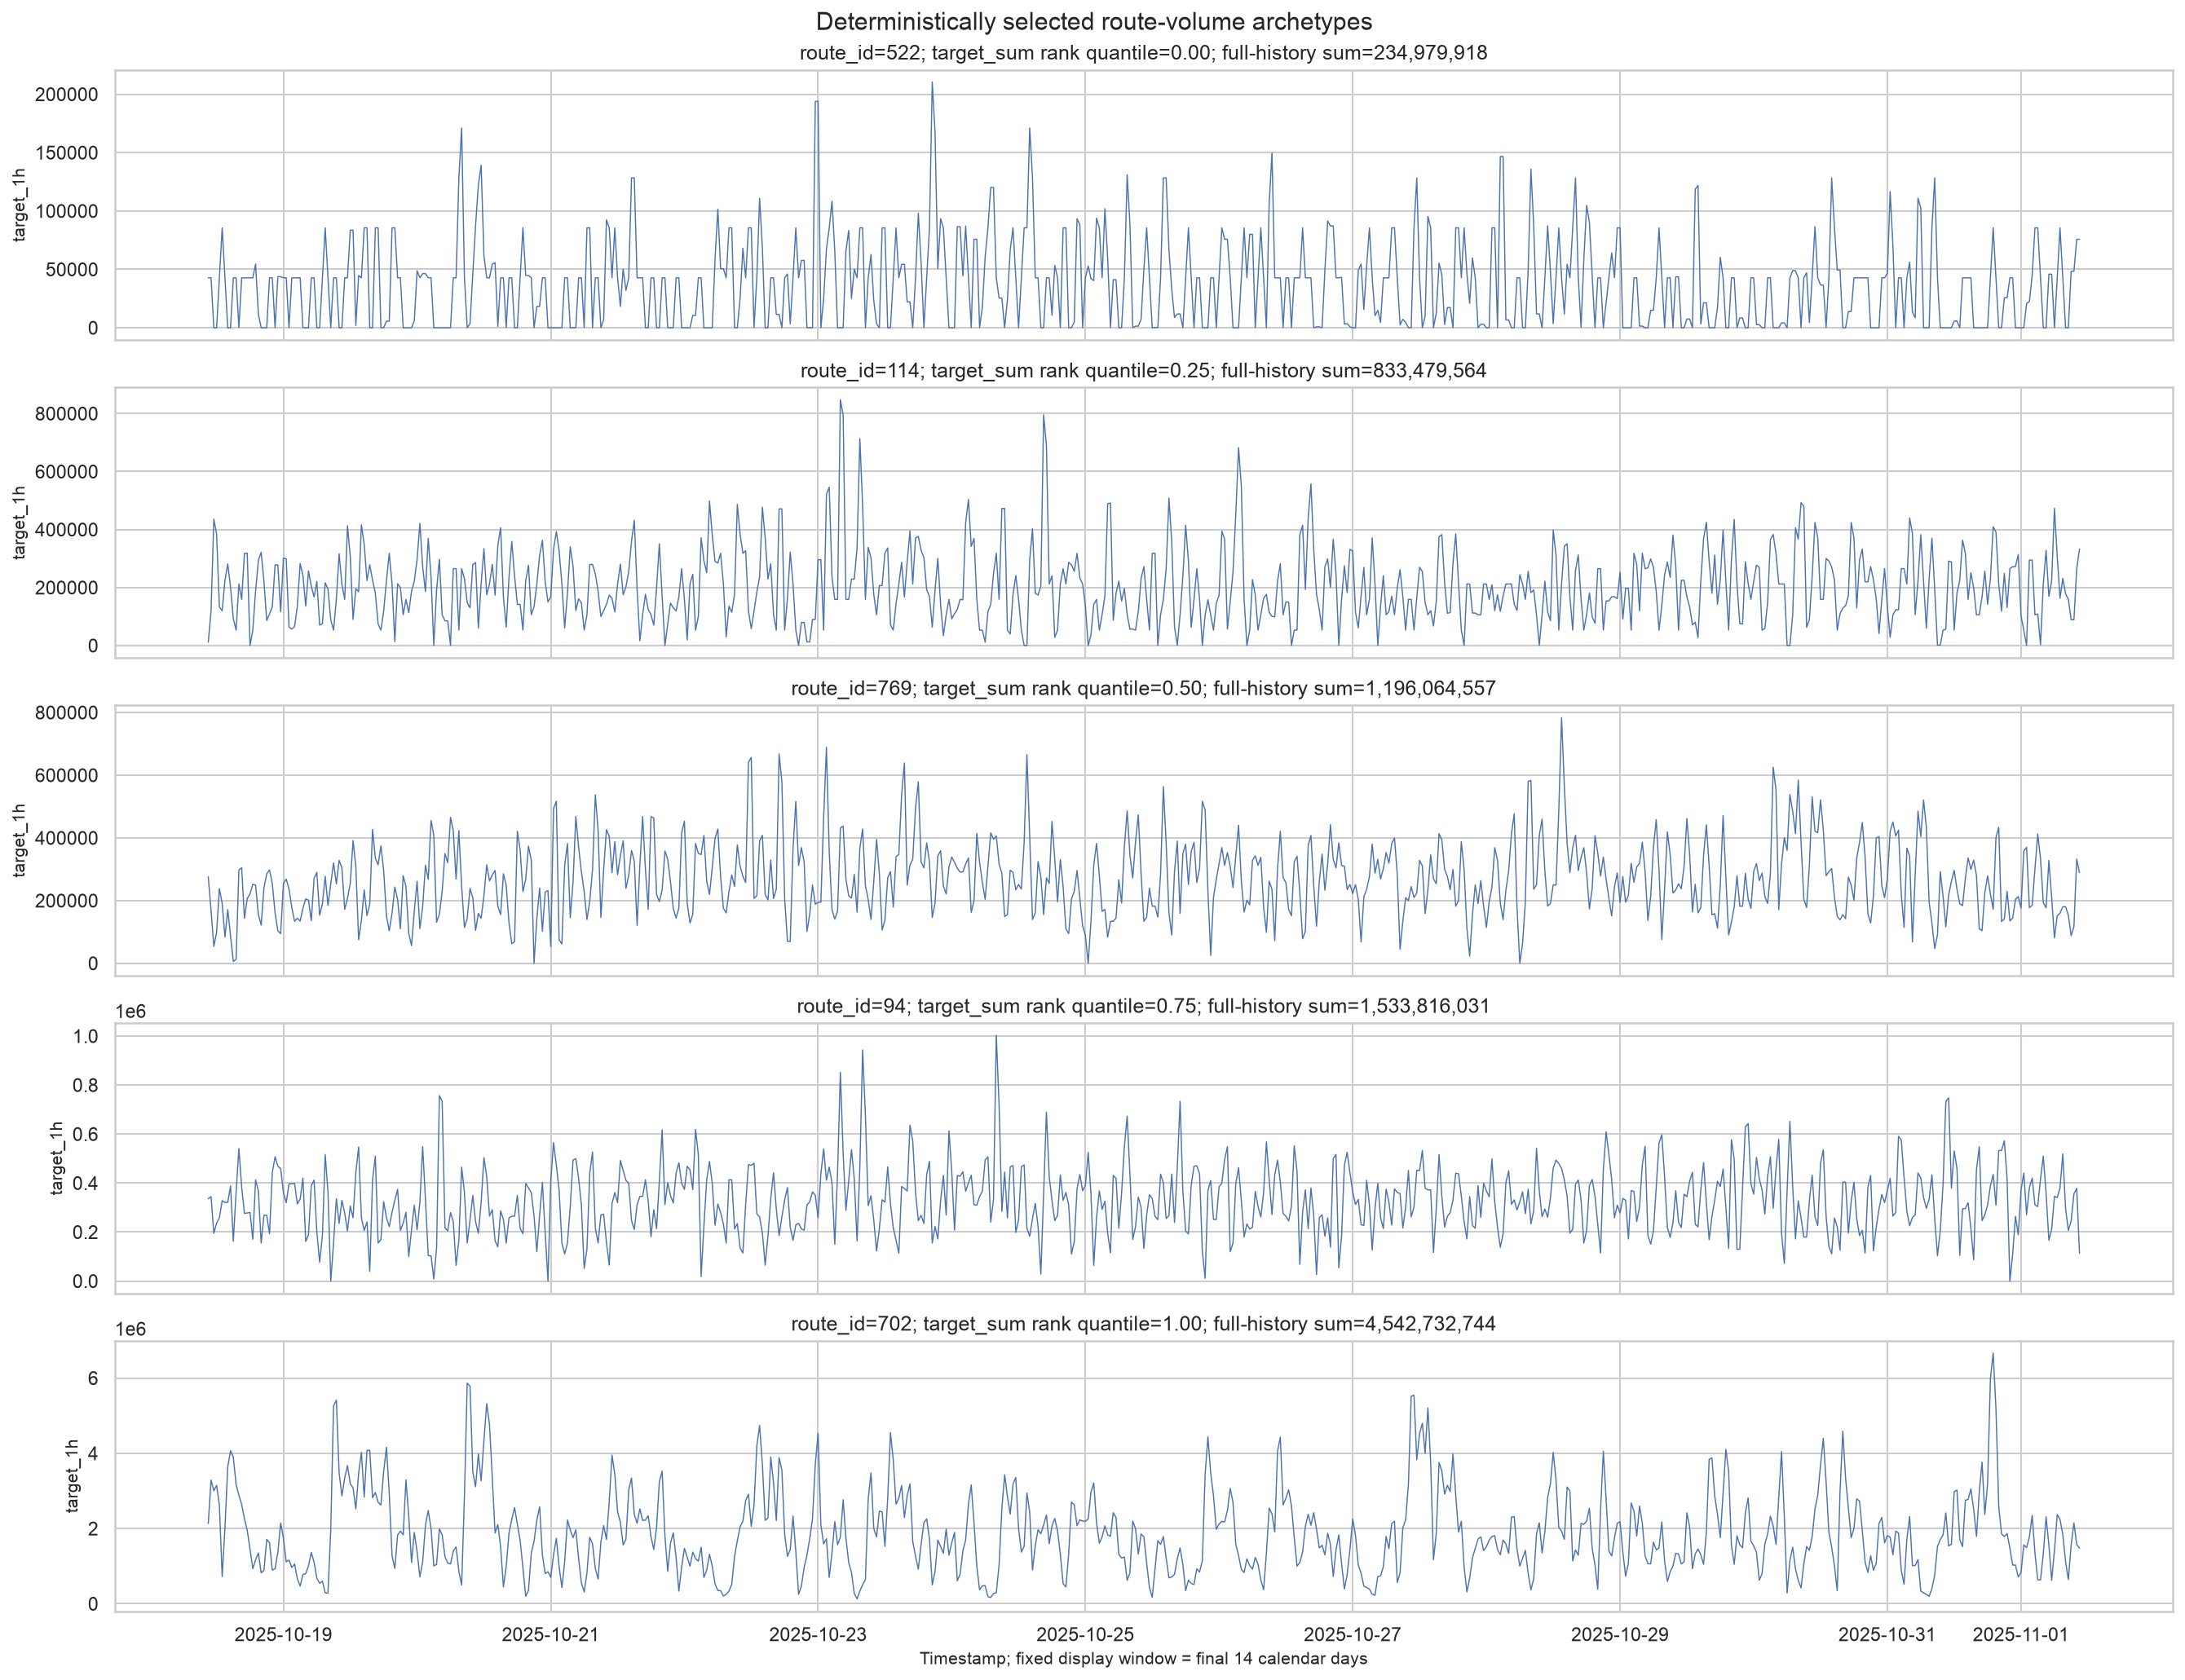

In [9]:
display(tables['route_summary'])
display(Image(filename=str(PLOT_DIR / '04_route_heterogeneity.png')))
display(Image(filename=str(PLOT_DIR / '08_route_archetypes_last_14_days.png')))

## 9. Временные профили

Дневная сумма, профиль 30-минутного слота и день недели считаются отдельно. Неполные календарные дни сохраняются и маркируются красным, чтобы частичный последний день не выглядел как падение бизнеса.

,date,rows,observed_slots,total,mean,median,slot_coverage_pct,complete_48_slot_day
0,2025-07-28,48000,48,9865437862,"205,530","185,104",100,True
1,2025-07-29,48000,48,10310162920,"214,795","193,396",100,True
2,2025-07-30,48000,48,10499031364,"218,730","197,960",100,True
3,2025-07-31,48000,48,10543771444,"219,662","199,519",100,True
4,2025-08-01,48000,48,10425104564,"217,190","195,881",100,True


,date,rows,observed_slots,total,mean,median,slot_coverage_pct,complete_48_slot_day
92,2025-10-28,48000,48,13168417555,"274,342","249,166",100,True
93,2025-10-29,48000,48,13321372526,"277,529","250,904",100,True
94,2025-10-30,48000,48,13415085256,"279,481","252,638",100,True
95,2025-10-31,48000,48,13060628853,"272,096","246,676",100,True
96,2025-11-01,22000,22,5809948140,"264,089","238,740",45.8333,False


,slot_of_day,rows,total,mean,median
0,0,97000,25848858725,"266,483","242,352"
1,1,97000,25828732504,"266,276","242,562"
2,2,97000,25039658602,"258,141","233,568"
3,3,97000,24269670439,"250,203","225,376"
4,4,97000,24372391360,"251,262","227,331"
5,5,97000,25071138619,"258,465","233,454"
6,6,97000,25208252982,"259,879","235,466"
7,7,97000,25518071905,"263,073","239,473"
8,8,97000,26035918749,"268,412","244,877"
9,9,97000,25325050830,"261,083","236,930"


,day_of_week,day_name,rows,total,mean,median
0,0,Monday,672000,169187579449,"251,767","226,696"
1,1,Tuesday,672000,175660097875,"261,399","235,647"
2,2,Wednesday,672000,179762250893,"267,503","241,898"
3,3,Thursday,672000,180053671834,"267,937","242,637"
4,4,Friday,672000,177657905265,"264,372","238,750"
5,5,Saturday,646000,168225914568,"260,412","235,172"
6,6,Sunday,624000,159003678424,"254,814","229,764"


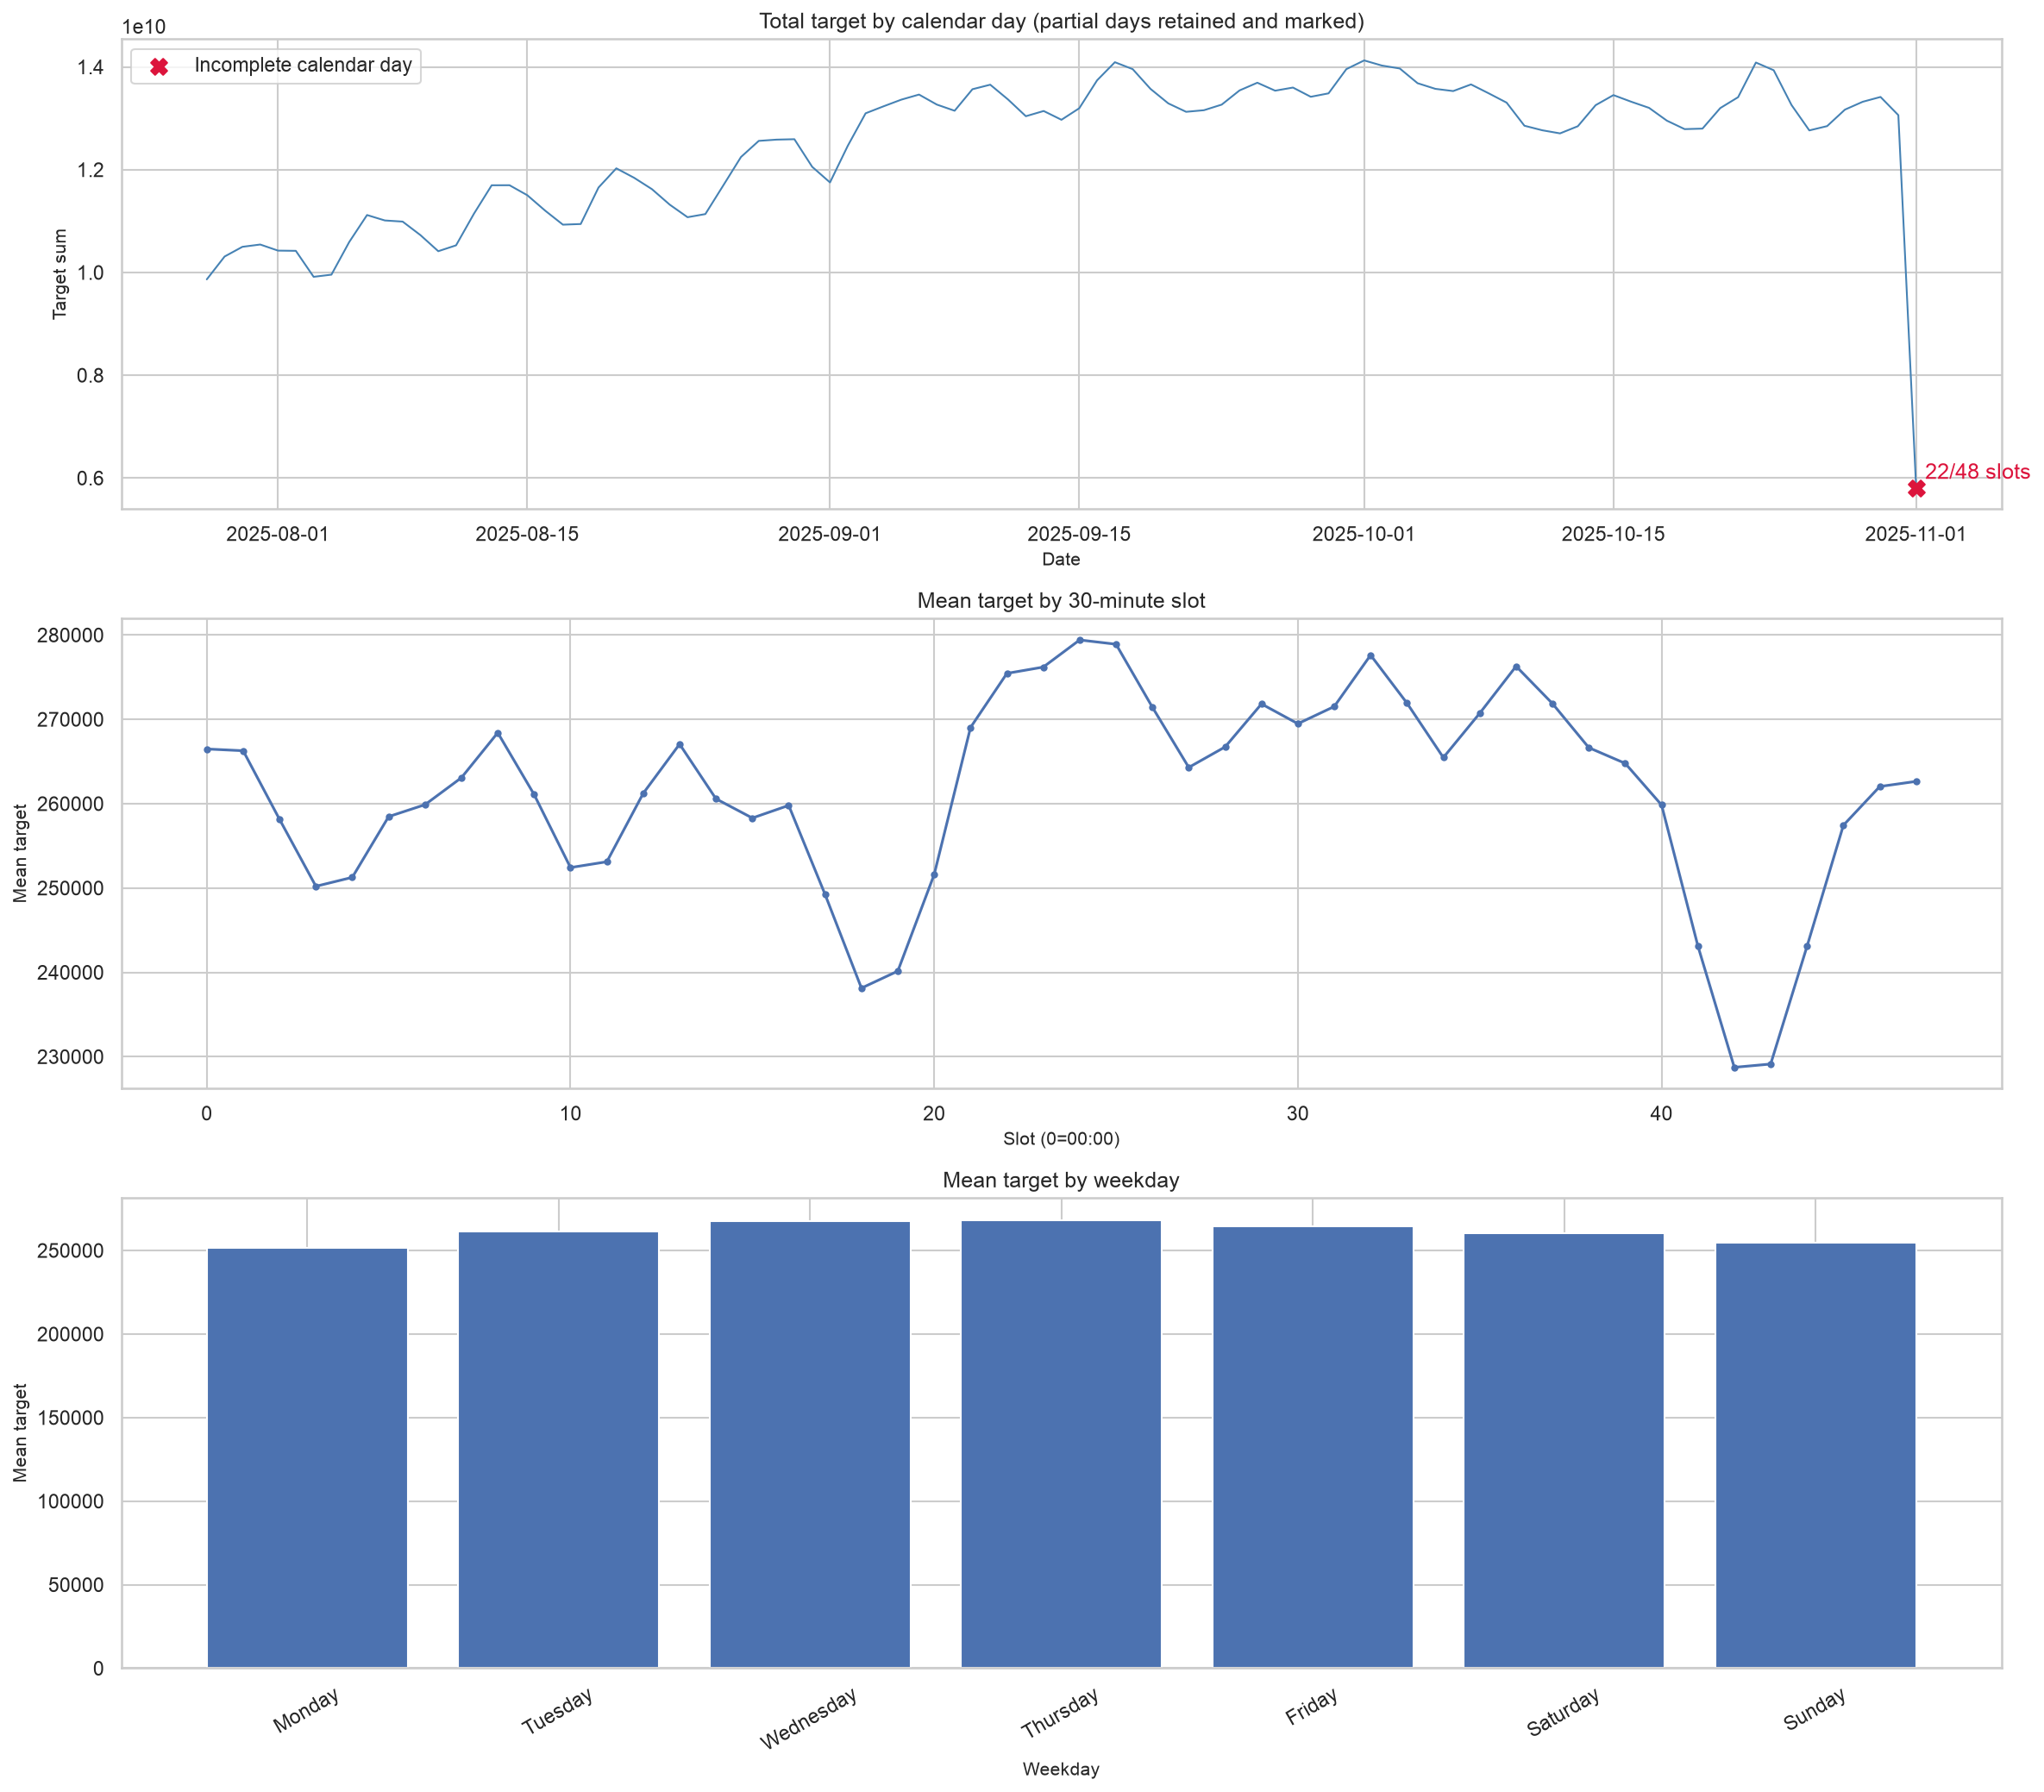

In [10]:
display(tables['daily_profile'].head())
display(tables['daily_profile'].tail())
display(tables['slot_profile'])
display(tables['weekday_profile'])
display(Image(filename=str(PLOT_DIR / '05_temporal_profiles.png')))

## 10. Описательные связи и автокорреляция

Pearson correlation измеряет линейную совместную изменчивость. Она не доказывает причинность, не учитывает route fixed effects и сама по себе не подтверждает доступность признака в момент прогноза. Автокорреляция считается внутри маршрутов на заранее перечисленных лагах.

,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
status_1,1,0.676288,0.412179,0.49451,0.432929,0.0731215,0.487596
status_2,0.676288,1,0.426922,0.503823,0.438954,0.0743608,0.506527
status_3,0.412179,0.426922,1,0.335429,0.289051,0.0495013,0.450902
status_4,0.49451,0.503823,0.335429,1,0.879529,0.179548,0.431177
status_5,0.432929,0.438954,0.289051,0.879529,1,0.190155,0.369687
status_6,0.0731215,0.0743608,0.0495013,0.179548,0.190155,1,0.10446
target_1h,0.487596,0.506527,0.450902,0.431177,0.369687,0.10446,1


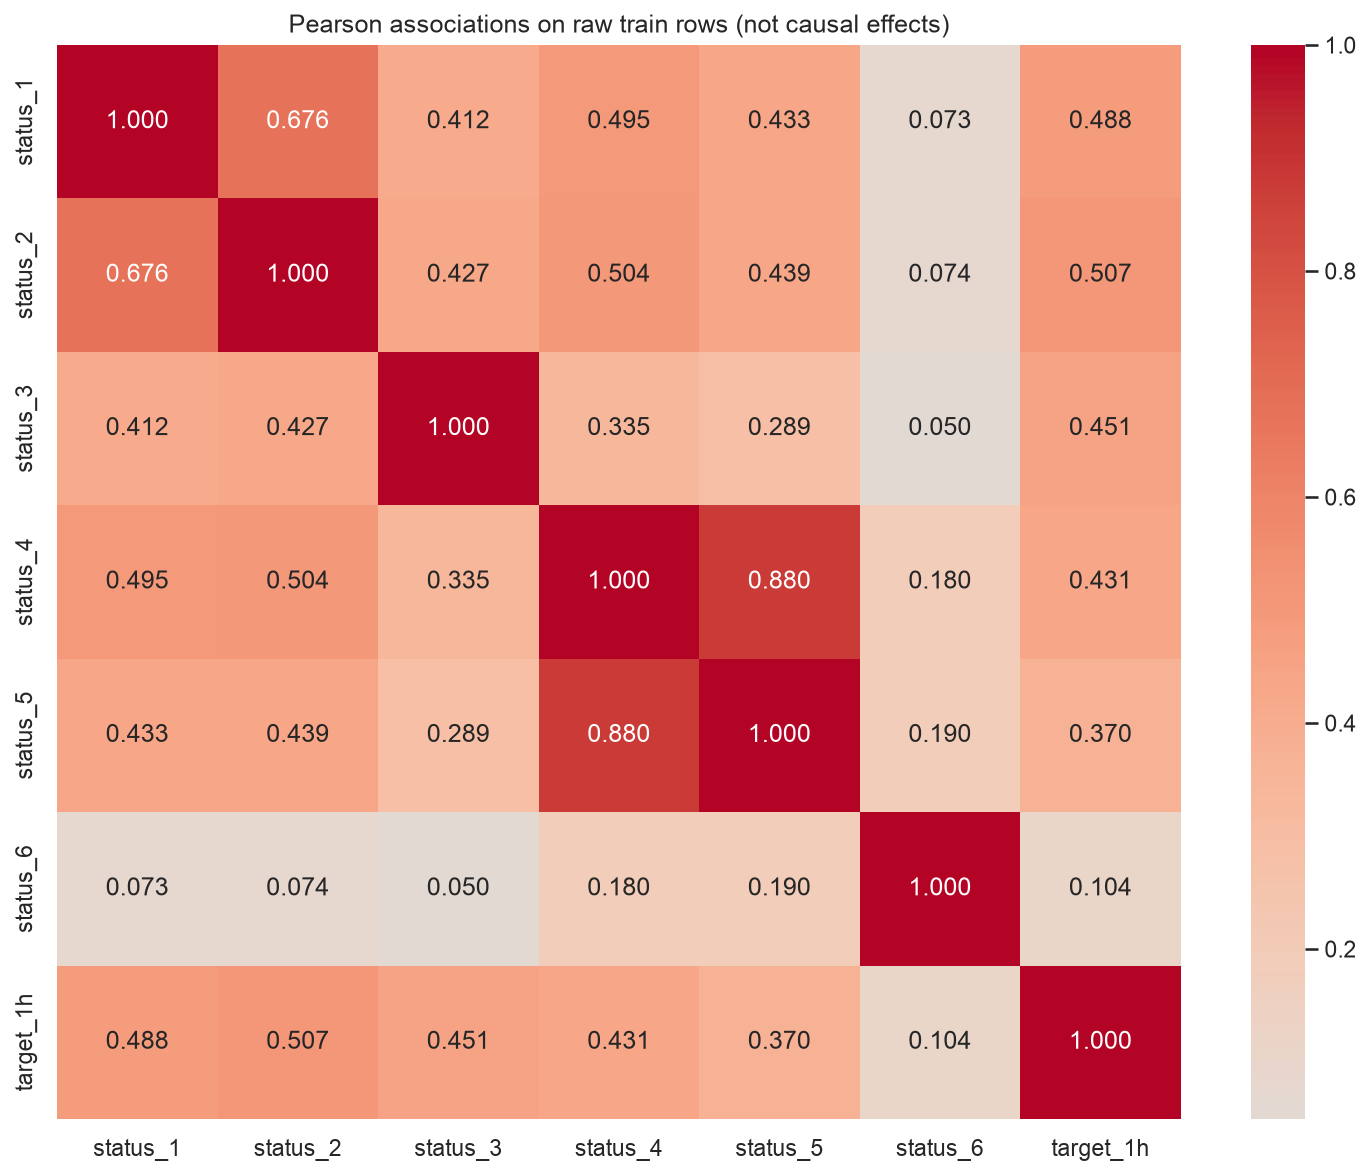

,lag_steps,pair_count,pearson_correlation
0,1,4629000,0.684265
1,2,4628000,0.384371
2,3,4627000,0.413955
3,4,4626000,0.434706
4,6,4624000,0.451207
5,12,4618000,0.452113
6,24,4606000,0.473705
7,48,4582000,0.497121
8,96,4534000,0.488812
9,336,4294000,0.480359


In [11]:
display(tables['correlations'])
display(Image(filename=str(PLOT_DIR / '06_raw_pearson_correlations.png')))
display(tables['autocorrelations'])

### Decision checkpoint B — prediction contract and leakage

Train содержит `status_1`…`status_6`, а test — нет. Перед использованием status нужно выбрать и защитить один контракт:

1. **Snapshot:** для всех восьми горизонтов доступны только status последнего train-момента.
2. **Forecasted status:** status сначала прогнозируются отдельной моделью.
3. **Target-history only:** status не используются, строятся лаги target и календарные признаки.
4. **Ансамбль контрактов:** несколько честных моделей с разными наборами доступных признаков.

Будущие или вычисленные по всей истории status/target нельзя незаметно использовать в validation.

## 11. Машинные инварианты

Эти проверки должны выполняться при чистом перезапуске. `REVIEW` не маскируется: он означает, что структурное предположение требует решения.

In [12]:
display(tables['assertions'])
assert tables['assertions']['passed'].all(), tables['assertions'].query('not passed')

,assertion,passed,status
0,train_has_rows,True,PASS
1,test_has_rows,True,PASS
2,train_route_timestamp_is_unique,True,PASS
3,test_route_timestamp_is_unique,True,PASS
4,test_id_is_unique,True,PASS
5,all_test_routes_exist_in_train,True,PASS
6,time_step_is_positive,True,PASS
7,test_horizons_are_integer_steps,True,PASS
8,target_has_no_missing,True,PASS


## 12. Факты первого прохода, собранные кодом

Следующая таблица собирает только проверенные значения. Интерпретация и решения вынесены в checkpoints.

In [13]:
key = tables['key_report'].set_index('check')['value']
time = tables['time_overview'].set_index('metric')['value']
horizon = tables['horizon_overview'].set_index('metric')['value']
target = tables['target_report'].set_index('metric')['value']
facts = pd.DataFrame({
    'fact': [
        'train rows', 'test rows', 'routes in train', 'routes in test',
        'duplicate train keys', 'missing time slots', 'modal step, minutes',
        'minimum horizon', 'maximum horizon', 'target zero rows',
        'target negative rows', 'target maximum'
    ],
    'value': [
        key['train_rows'], key['test_rows'], key['train_route_count'], key['test_route_count'],
        key['train_duplicate_key_rows'], time['total_missing_slots_between_own_bounds'],
        time['modal_positive_step_minutes'], horizon['minimum_horizon_steps'],
        horizon['maximum_horizon_steps'], target['zero_rows'],
        target['negative_rows'], target['maximum']
    ]
})
display(facts)

,fact,value
0,train rows,4.63e+06
1,test rows,"8,000"
2,routes in train,"1,000"
3,routes in test,"1,000"
4,duplicate train keys,0
5,missing time slots,0
6,"modal step, minutes",30
7,minimum horizon,1
8,maximum horizon,8
9,target zero rows,"69,841"


# Часть II. Углублённый EDA без моделирования

Следующий блок исследует несколько альтернативных представлений одних данных. Он не выбирает способ очистки, признаки, split или модель.

In [14]:
started = perf_counter()
deep_audit = run_deep_audit(bundle)
deep_tables = deep_audit['tables']
print(f'Deep audit completed in {perf_counter() - started:.2f} seconds')
print(deep_audit['metadata'])

Deep audit completed in 9.87 seconds
{'raw_data_mutated': False, 'rows_dropped': 0, 'values_clipped': 0, 'values_imputed': 0, 'model_trained': False, 'tables_exported': ['periodogram', 'quarter_summary', 'route_quarter', 'route_zero', 'segment_summary', 'segmented_routes', 'stability_overview', 'status_lead_lag', 'tail_by_date', 'tail_by_route', 'tail_overview', 'top_tail_events', 'weekly_stability', 'zero_by_date', 'zero_by_slot', 'zero_overview', 'zero_runs'], 'plots_exported': ['01_missingness.png', '02_target_distribution.png', '03_status_distributions.png', '04_route_heterogeneity.png', '05_temporal_profiles.png', '06_raw_pearson_correlations.png', '07_test_horizons.png', '08_route_archetypes_last_14_days.png', '09_zero_patterns.png', '10_upper_tail_patterns.png', '11_status_lead_lag.png', '12_temporal_stability_and_spectrum.png', '13_route_segmentations.png']}


## 14. Нулевые значения: маршруты, время и последовательности

Ноль может быть валидным отсутствием отгрузки, режимом конкретного маршрута или техническим событием. Код не выбирает трактовку: он измеряет распределение нулей и длины непрерывных серий.

,metric,value
0,zero_rows,"69,841"
1,zero_pct,1.50844
2,routes_with_at_least_one_zero,865
3,routes_without_zeros,135
4,median_route_zero_pct,0.215983
5,maximum_route_zero_pct,23.2397
6,zero_run_count,"52,438"
7,median_zero_run_steps,1
8,maximum_zero_run_steps,135


**Маршруты с наибольшей долей нулей**

,route_id,rows,zero_rows,target_mean,target_median,zero_pct
142,142,4630,1076,"62,575.4","55,884",23.2397
853,853,4630,1051,"59,637.6","38,855",22.6998
250,250,4630,1047,"69,036.8","54,245",22.6134
522,522,4630,968,"50,751.6","42,786",20.9071
728,728,4630,954,"72,926.2","50,571",20.6048
742,742,4630,945,"62,149.3","46,372",20.4104
475,475,4630,903,"69,000.7","51,348",19.5032
417,417,4630,861,"80,576.5","49,270.5",18.5961
840,840,4630,810,"77,734","57,323",17.4946
790,790,4630,796,"70,387.8","54,375",17.1922


**Самые длинные непрерывные серии нулей**

,route_id,run_id,run_start,run_end,run_steps,run_hours
38213,742,3685,2025-10-29 15:30:00,2025-11-01 10:30:00,135,67.5
38211,742,3681,2025-10-28 14:00:00,2025-10-29 12:30:00,46,23
38210,742,3679,2025-10-27 16:30:00,2025-10-28 12:30:00,41,20.5
38208,742,3674,2025-10-26 20:00:00,2025-10-27 05:30:00,20,10
40927,793,727,2025-08-16 14:00:00,2025-08-16 22:30:00,18,9
38209,742,3676,2025-10-27 07:00:00,2025-10-27 14:30:00,16,8
22747,450,3980,2025-10-28 01:00:00,2025-10-28 07:30:00,14,7
12259,250,578,2025-08-10 16:00:00,2025-08-10 21:00:00,11,5.5
12389,250,1163,2025-08-30 09:00:00,2025-08-30 14:00:00,11,5.5
22769,450,4039,2025-10-31 06:00:00,2025-10-31 11:00:00,11,5.5


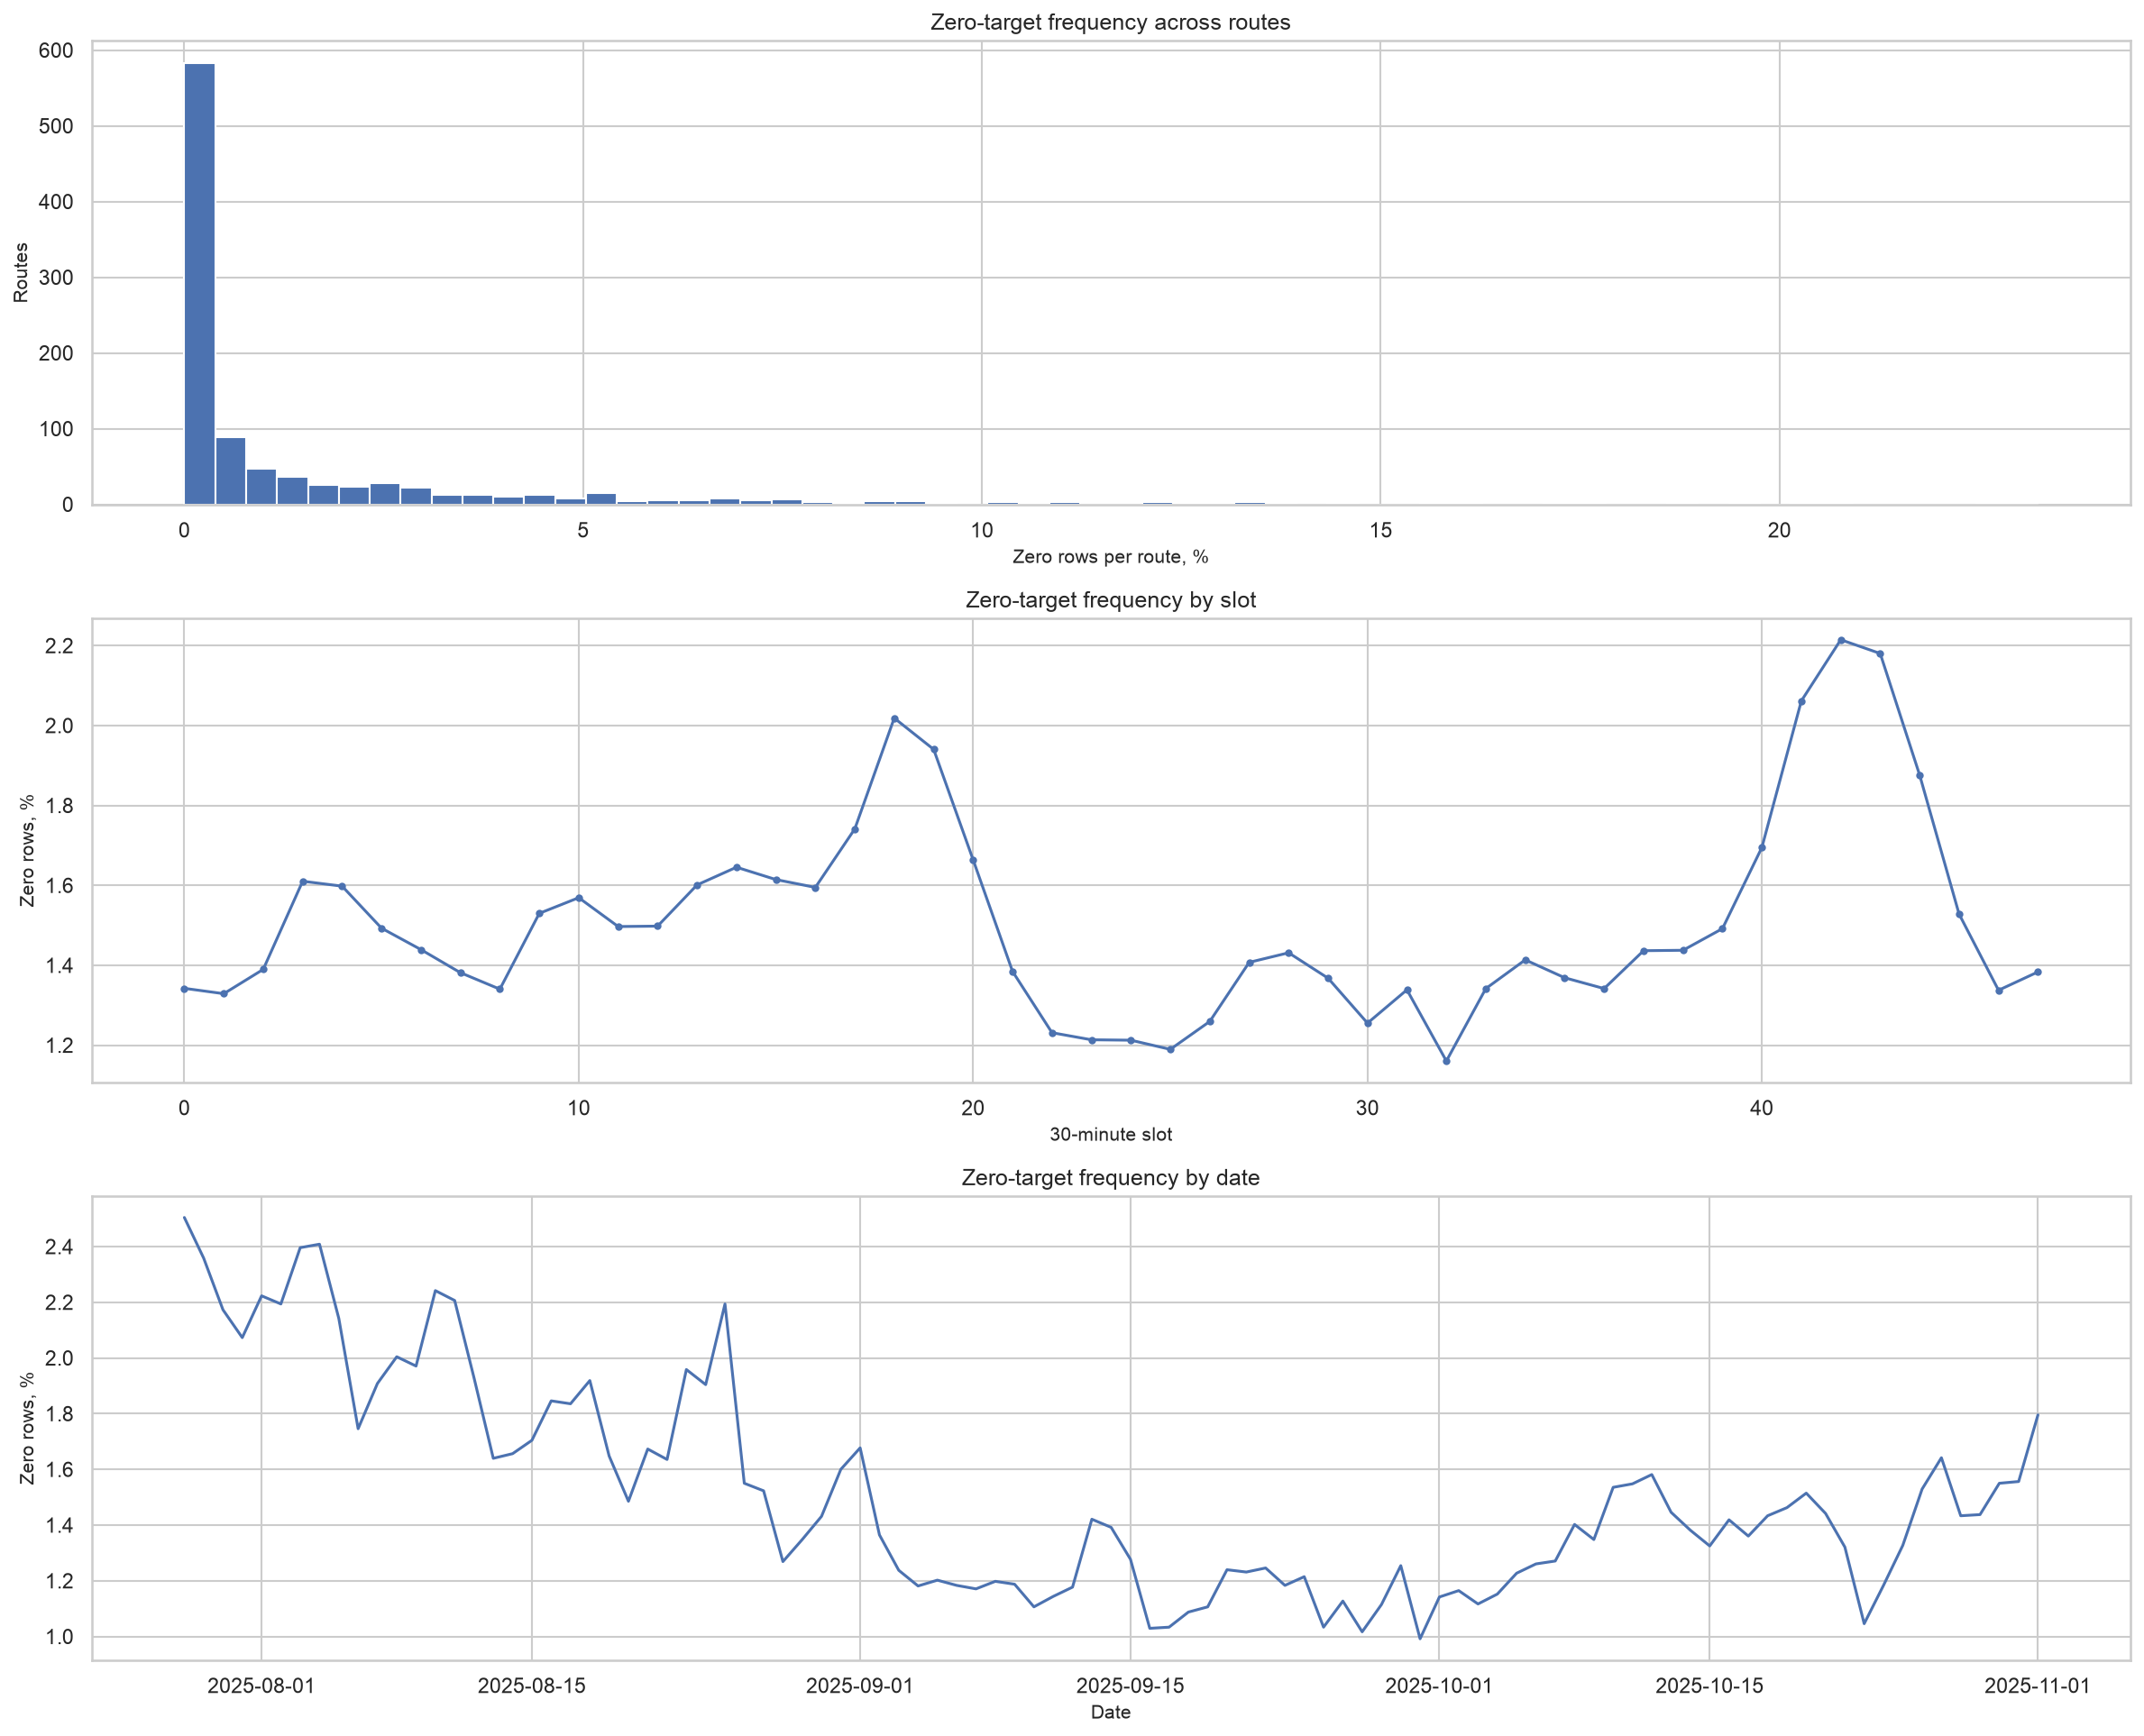

In [15]:
display(deep_tables['zero_overview'])
display(Markdown('**Маршруты с наибольшей долей нулей**'))
display(deep_tables['route_zero'].sort_values('zero_pct', ascending=False).head(25))
display(Markdown('**Самые длинные непрерывные серии нулей**'))
display(deep_tables['zero_runs'].head(25))
display(Image(filename=str(PLOT_DIR / '09_zero_patterns.png')))

## 15. Верхний хвост: глобальные и route-relative масштабы

Глобальный порог может преимущественно выбирать крупные маршруты. Поэтому рядом выводятся представительство маршрутов, доля общего target и отношение события к медиане его собственного маршрута. Никакой порог не используется для удаления строк.

,threshold_name,threshold,rows_strictly_above,row_pct,target_share,routes_represented,timestamps_represented
0,p99,"743,427",46300,1,0.0343923,678,4496
1,p99_9,1.02654e+06,4630,0.1,0.00591646,303,2504
2,tukey_upper,"679,452",83306,1.79927,0.0560646,768,4617


**50 наибольших наблюдений с масштабом относительно медианы маршрута**

,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h,route_median,multiple_of_route_median
0,791,2025-09-22 22:00:00,31,104,107,360600,2211313,10576,10831337,"389,016",27.8429
1,791,2025-09-22 22:30:00,34,31,13,354040,2222939,10674,10624056,"389,016",27.31
2,305,2025-09-22 22:00:00,50,117,93,235487,1849407,446,9848062,"414,073",23.7834
3,305,2025-09-22 22:30:00,48,35,17,235025,1852598,440,9258881,"414,073",22.3605
4,925,2025-10-09 11:00:00,28,28,46,155494,939523,26369,8528777,"407,504",20.9293
5,925,2025-10-29 10:00:00,36,42,43,134182,782387,19384,8071419,"407,504",19.807
6,50,2025-10-09 11:00:00,5,8,0,40163,236337,18012,7612138,"166,271",45.7815
7,50,2025-10-29 10:00:00,8,18,2,41240,256007,16253,7489139,"166,271",45.0418
8,925,2025-08-29 11:00:00,24,47,24,145802,790429,19011,7185416,"407,504",17.6327
9,925,2025-10-02 05:00:00,19,42,30,203454,1191723,87215,6827128,"407,504",16.7535


**Маршруты, чаще всего попадающие выше глобального p99.9**

,route_id,tail_rows,tail_target_sum,tail_target_max
222,702,1436,2806964940,6664230
284,925,216,487560898,8528777
52,192,121,243551578,3903482
239,768,120,164287216,3441061
10,50,105,324664300,7612138
17,70,98,117695796,1640222
98,324,98,110064049,1533982
173,564,70,80417091,1375705
74,258,70,79295178,1434890
235,761,68,77365609,1343422


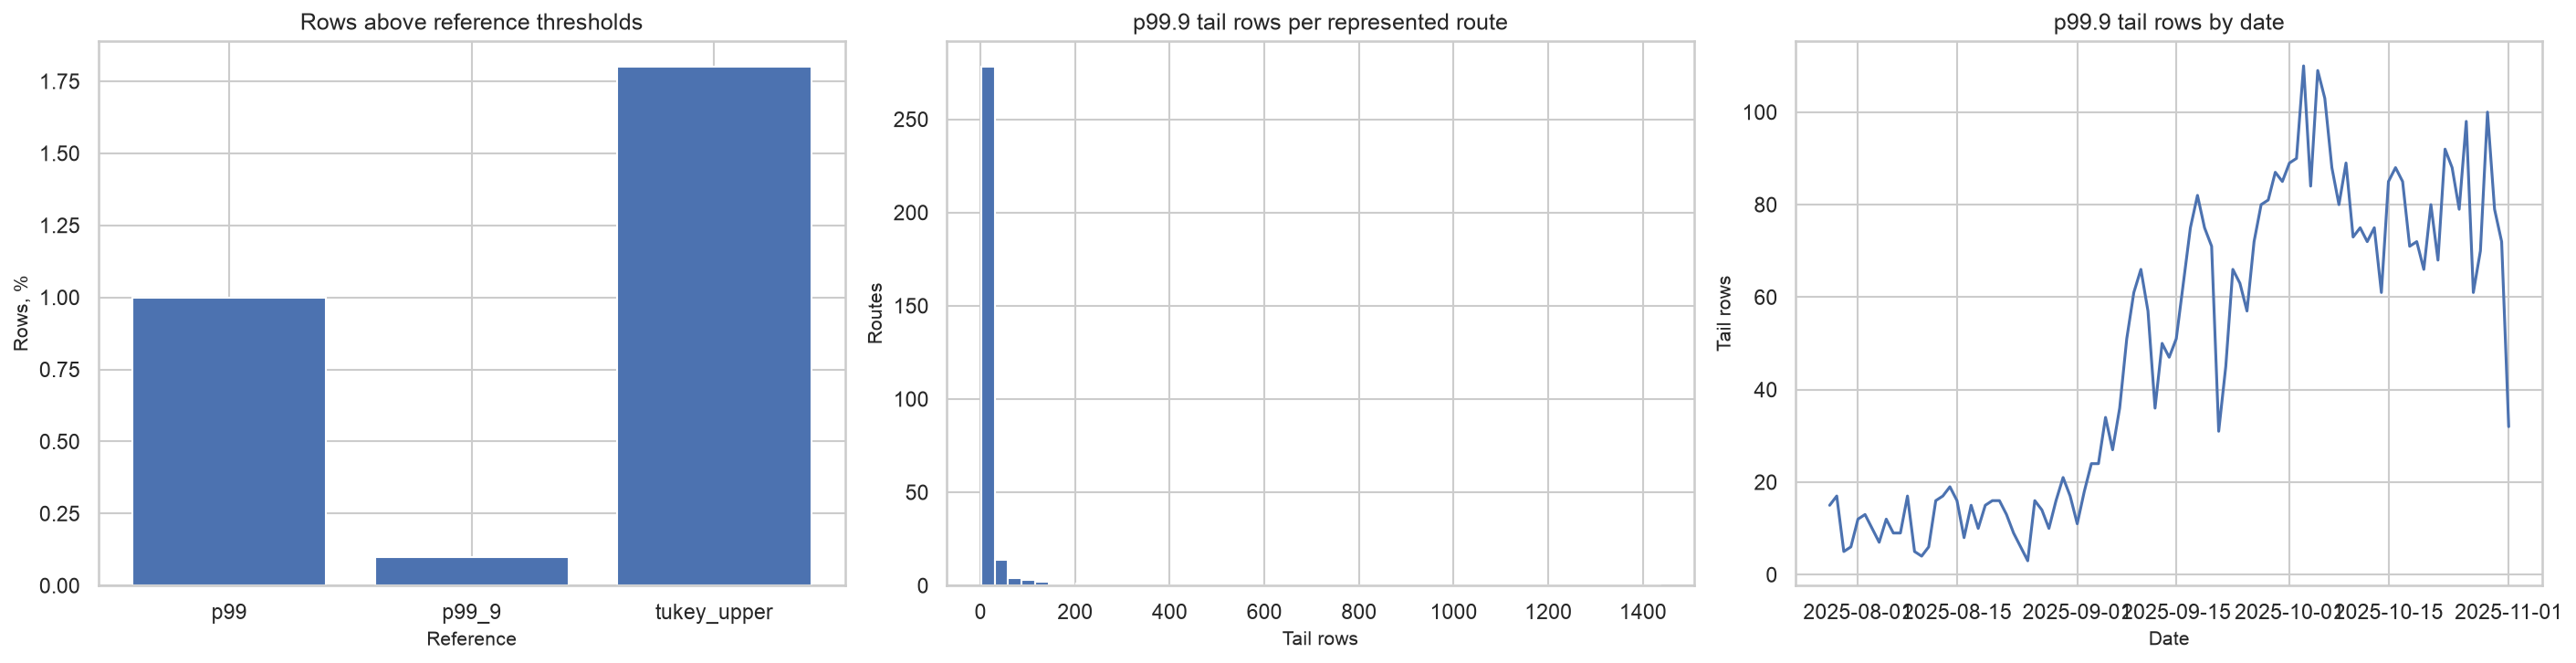

In [16]:
display(deep_tables['tail_overview'])
display(Markdown('**50 наибольших наблюдений с масштабом относительно медианы маршрута**'))
display(deep_tables['top_tail_events'])
display(Markdown('**Маршруты, чаще всего попадающие выше глобального p99.9**'))
display(deep_tables['tail_by_route'].head(30))
display(Image(filename=str(PLOT_DIR / '10_upper_tail_patterns.png')))

## 16. Lead–lag: `status(t)` и `target(t+h)`

Показываются два принципиально разных взгляда:

- raw correlation включает различия среднего масштаба между маршрутами;
- route-centered correlation вычитает исторический средний уровень каждого маршрута и лучше отражает совместную динамику внутри маршрута.

Оба варианта описательны и не гарантируют прирост out-of-time качества.

,horizon_steps,horizon_hours,status,pair_count,raw_pearson,route_centered_pearson
0,0,0,status_1,4630000,0.487596,0.0864152
1,0,0,status_2,4630000,0.506527,0.104522
2,0,0,status_3,4630000,0.450902,0.224119
3,0,0,status_4,4630000,0.431177,0.126474
4,0,0,status_5,4630000,0.369687,0.130261
5,0,0,status_6,4630000,0.10446,0.042345
6,1,0.5,status_1,4629000,0.499783,0.10958
7,1,0.5,status_2,4629000,0.533261,0.156618
8,1,0.5,status_3,4629000,0.564791,0.392819
9,1,0.5,status_4,4629000,0.431899,0.128094


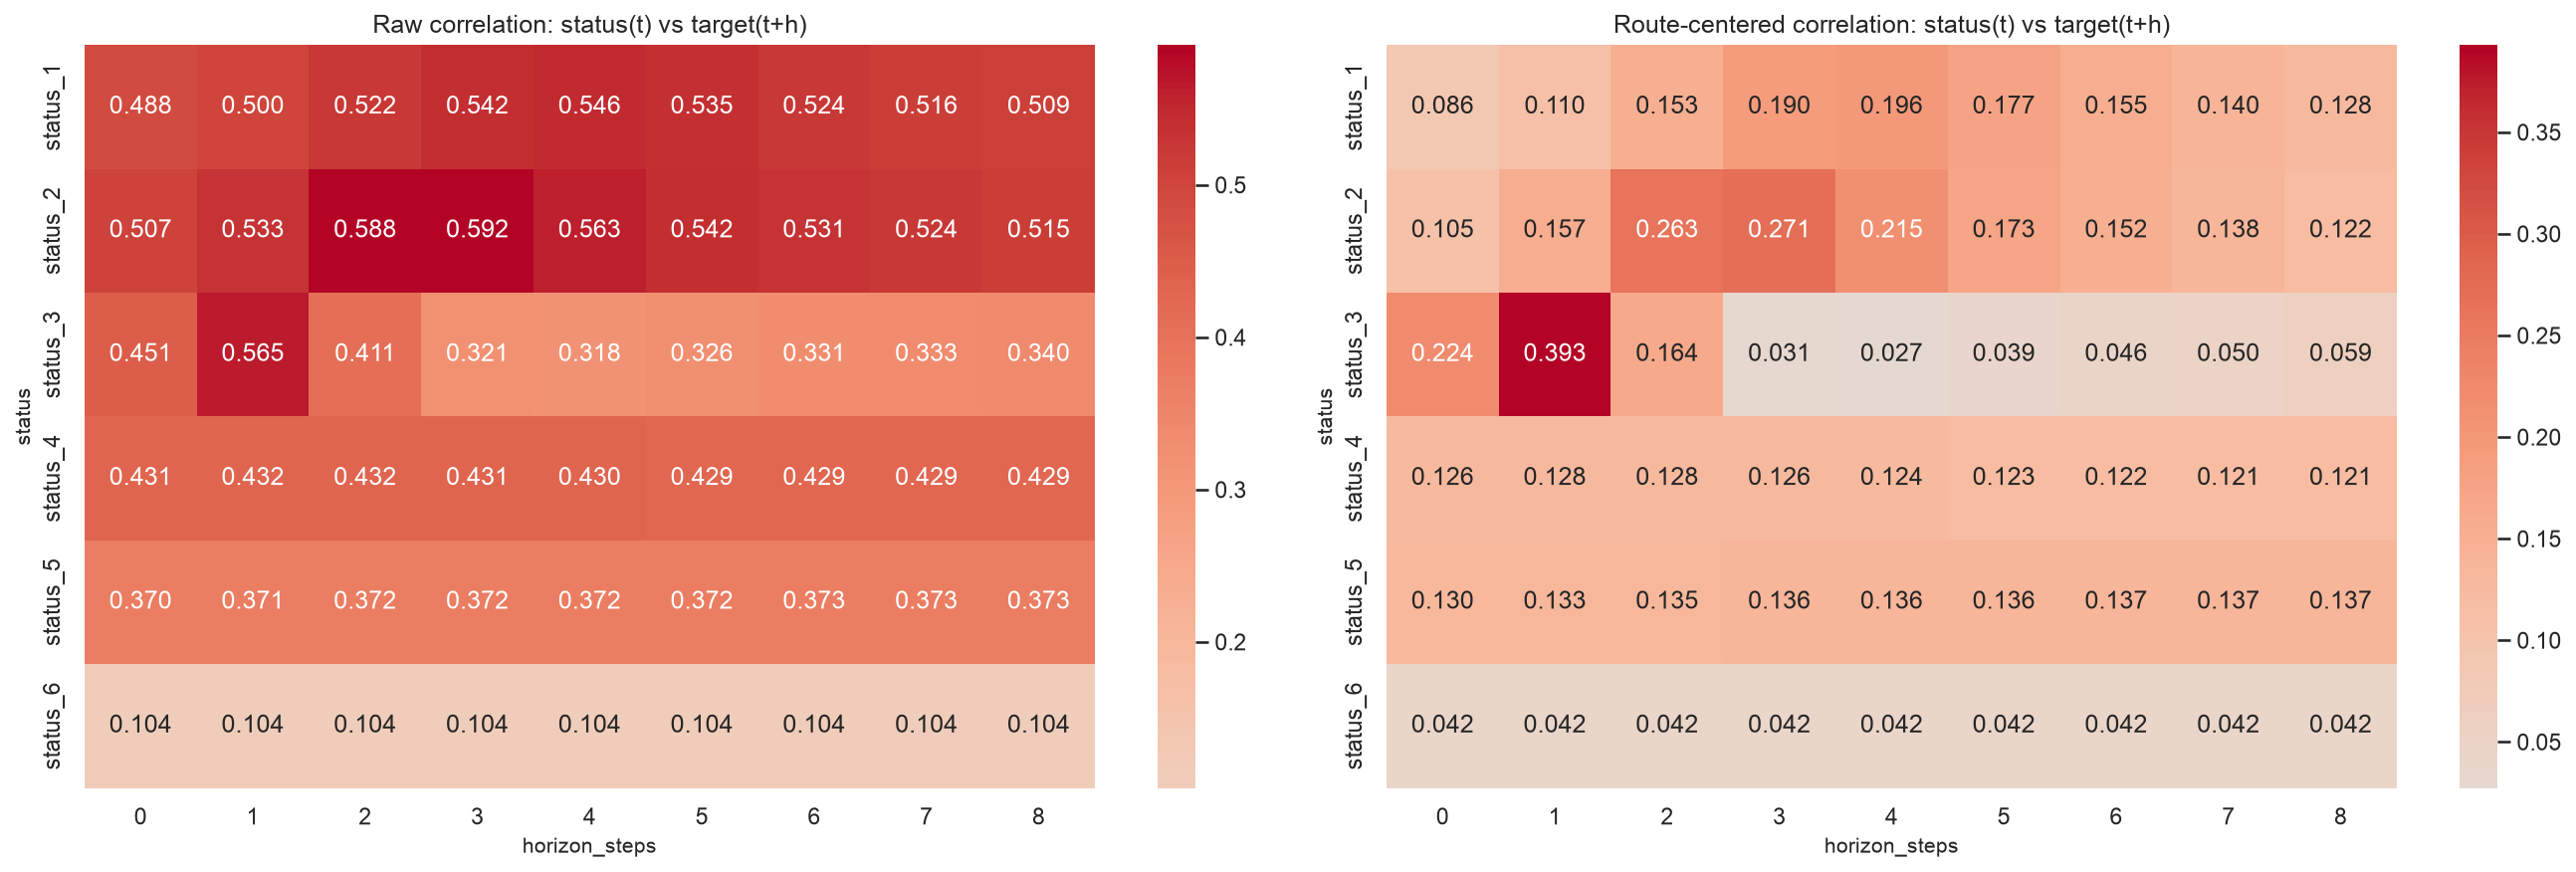

In [17]:
display(deep_tables['status_lead_lag'])
display(Image(filename=str(PLOT_DIR / '11_status_lead_lag.png')))

## 17. Нестационарность, устойчивость маршрутов и периодичность

История делится на четыре равных хронологических участка только для диагностики drift. Wasserstein distance сравнивает распределения первого и последнего участков. Spearman correlation проверяет устойчивость ранжирования маршрутов по среднему объёму. Periodogram строится по суммарному target после удаления линейного тренда.

,metric,value
0,history_start,2025-07-28 00:00:00
1,history_end,2025-11-01 10:30:00
2,latest_vs_earliest_mean_ratio,1.2137
3,latest_vs_earliest_median_ratio,1.2069
4,wasserstein_distance_earliest_latest,"48,282.9"
5,wasserstein_normalized_by_global_std,0.285558
6,route_mean_rank_spearman_earliest_latest,0.896438
7,route_mean_rank_spearman_pvalue,0


,time_quarter,rows,mean,median,std,minimum,maximum,zero_pct,p99
0,Q1_earliest,1158000,"225,942","205,196","144,894",0,6012005,2.00682,"640,709"
1,Q2,1157000,"261,543","238,266","162,186",0,7185416,1.42913,"725,621"
2,Q3,1157000,"283,277","256,974","180,063",0,10831337,1.16595,"794,977"
3,Q4_latest,1158000,"274,225","247,651","180,931",0,8528777,1.43152,"772,063"


**20 наиболее мощных периодов; длинные периоды могут отражать остаточный тренд**

,frequency_cycles_per_step,period_steps,period_hours,power,power_share
0,0.000215983,"4,630","2,315",7.05881e+17,0.296583
1,0.0207343,48.2292,24.1146,1.67364e+17,0.0703199
2,0.0416847,23.9896,11.9948,1.45564e+17,0.06116
3,0.0833693,11.9948,5.99741,1.44829e+17,0.0608513
4,0.00302376,330.714,165.357,1.29817e+17,0.054544
5,0.125054,7.99655,3.99827,1.28815e+17,0.0541229
6,0.0209503,47.732,23.866,1.1258e+17,0.0473017
7,0.0211663,47.2449,23.6224,3.62235e+16,0.0152197
8,0.000863931,"1,157.5",578.75,3.60494e+16,0.0151465
9,0.00215983,463,231.5,2.46815e+16,0.0103702


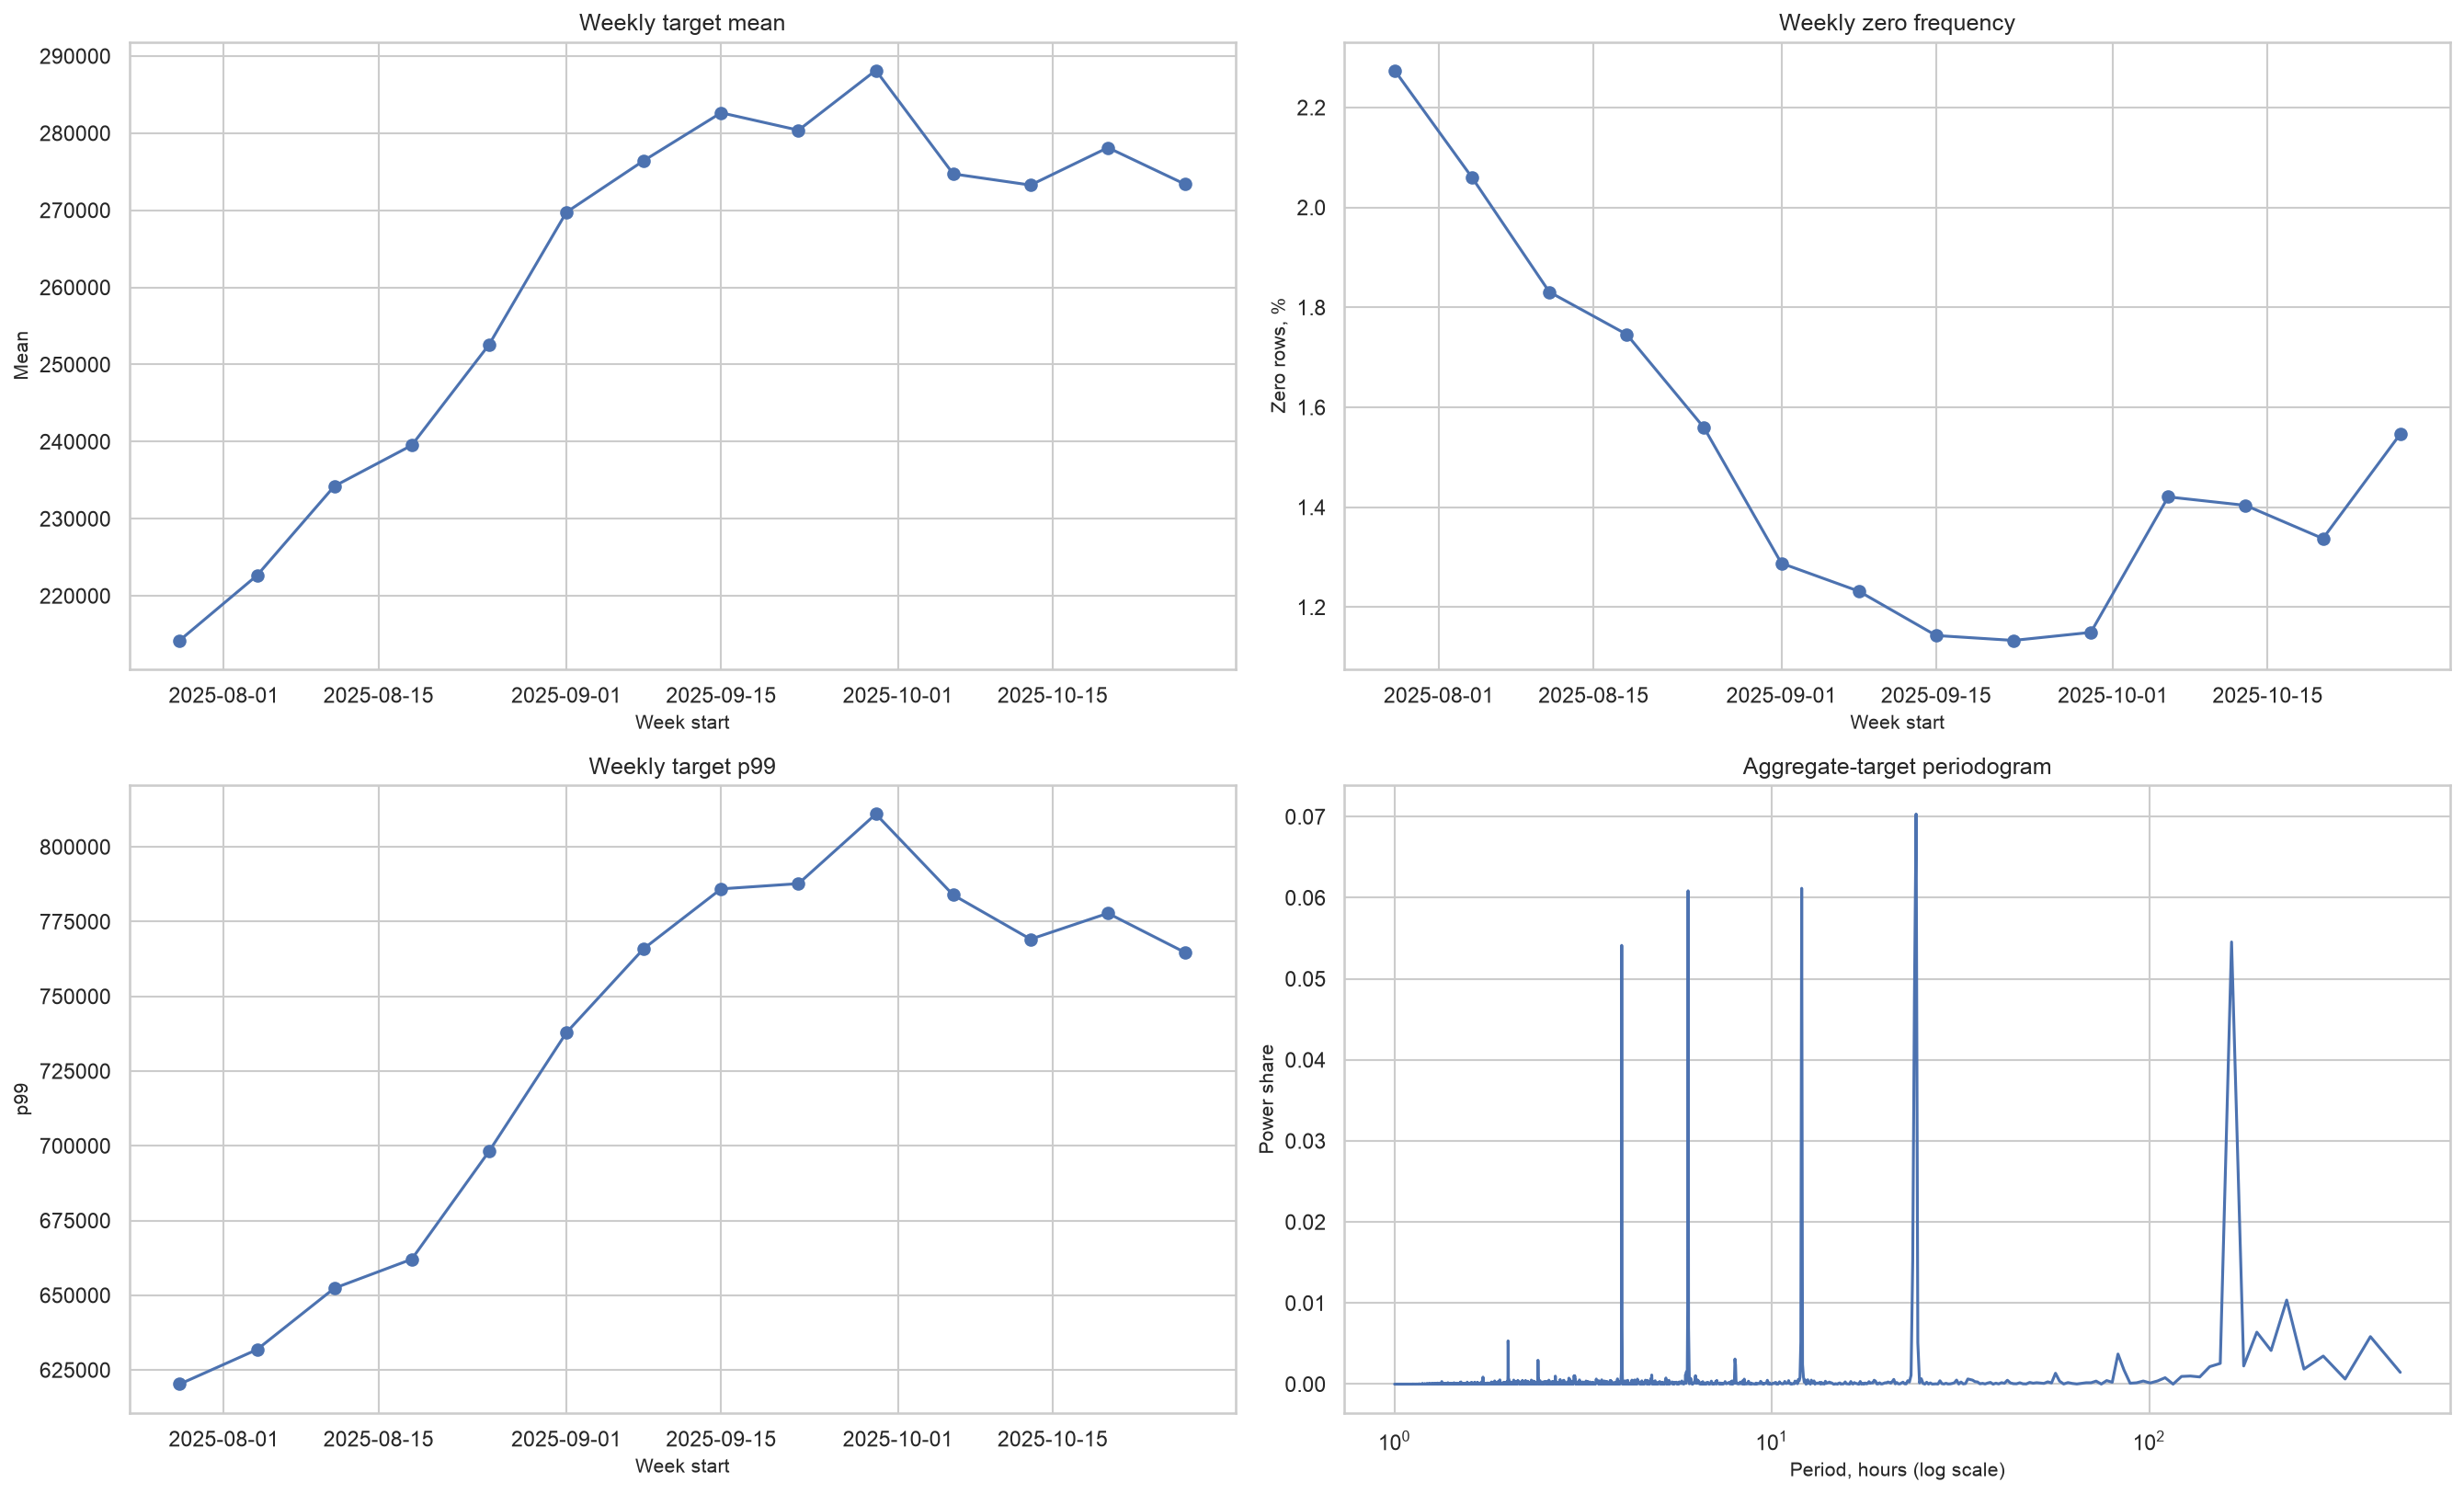

In [18]:
display(deep_tables['stability_overview'])
display(deep_tables['quarter_summary'])
display(Markdown('**20 наиболее мощных периодов; длинные периоды могут отражать остаточный тренд**'))
display(deep_tables['periodogram'].head(20))
display(Image(filename=str(PLOT_DIR / '12_temporal_stability_and_spectrum.png')))

## 18. Две оси сегментации маршрутов

Для проверки гипотезы mixture-of-experts одновременно показаны квинтили среднего объёма и коэффициента вариации. Это диагностическая сетка, а не выбранная архитектура модели.

,volume_quintile,variability_quintile,route_count,median_target_mean,median_cv,median_zero_pct,total_target_share
0,V1_low,C4,48,"140,673",0.578522,1.96544,0.0256897
1,V1_low,C5_variable,152,"116,195",0.683163,5.31317,0.06729
2,V2,C2,9,"215,049",0.447801,0.172786,0.00746384
3,V2,C3,51,"205,759",0.483001,0.323974,0.0396956
4,V2,C4,102,"190,559",0.541985,1.09071,0.075003
5,V2,C5_variable,38,"182,238",0.64312,2.5162,0.0268391
6,V3,C1_stable,8,"278,206",0.3947,0.0215983,0.0085015
7,V3,C2,57,"263,892",0.435262,0.0863931,0.0571372
8,V3,C3,91,"256,242",0.476915,0.259179,0.0892938
9,V3,C4,40,"250,864",0.521274,0.49676,0.0389657


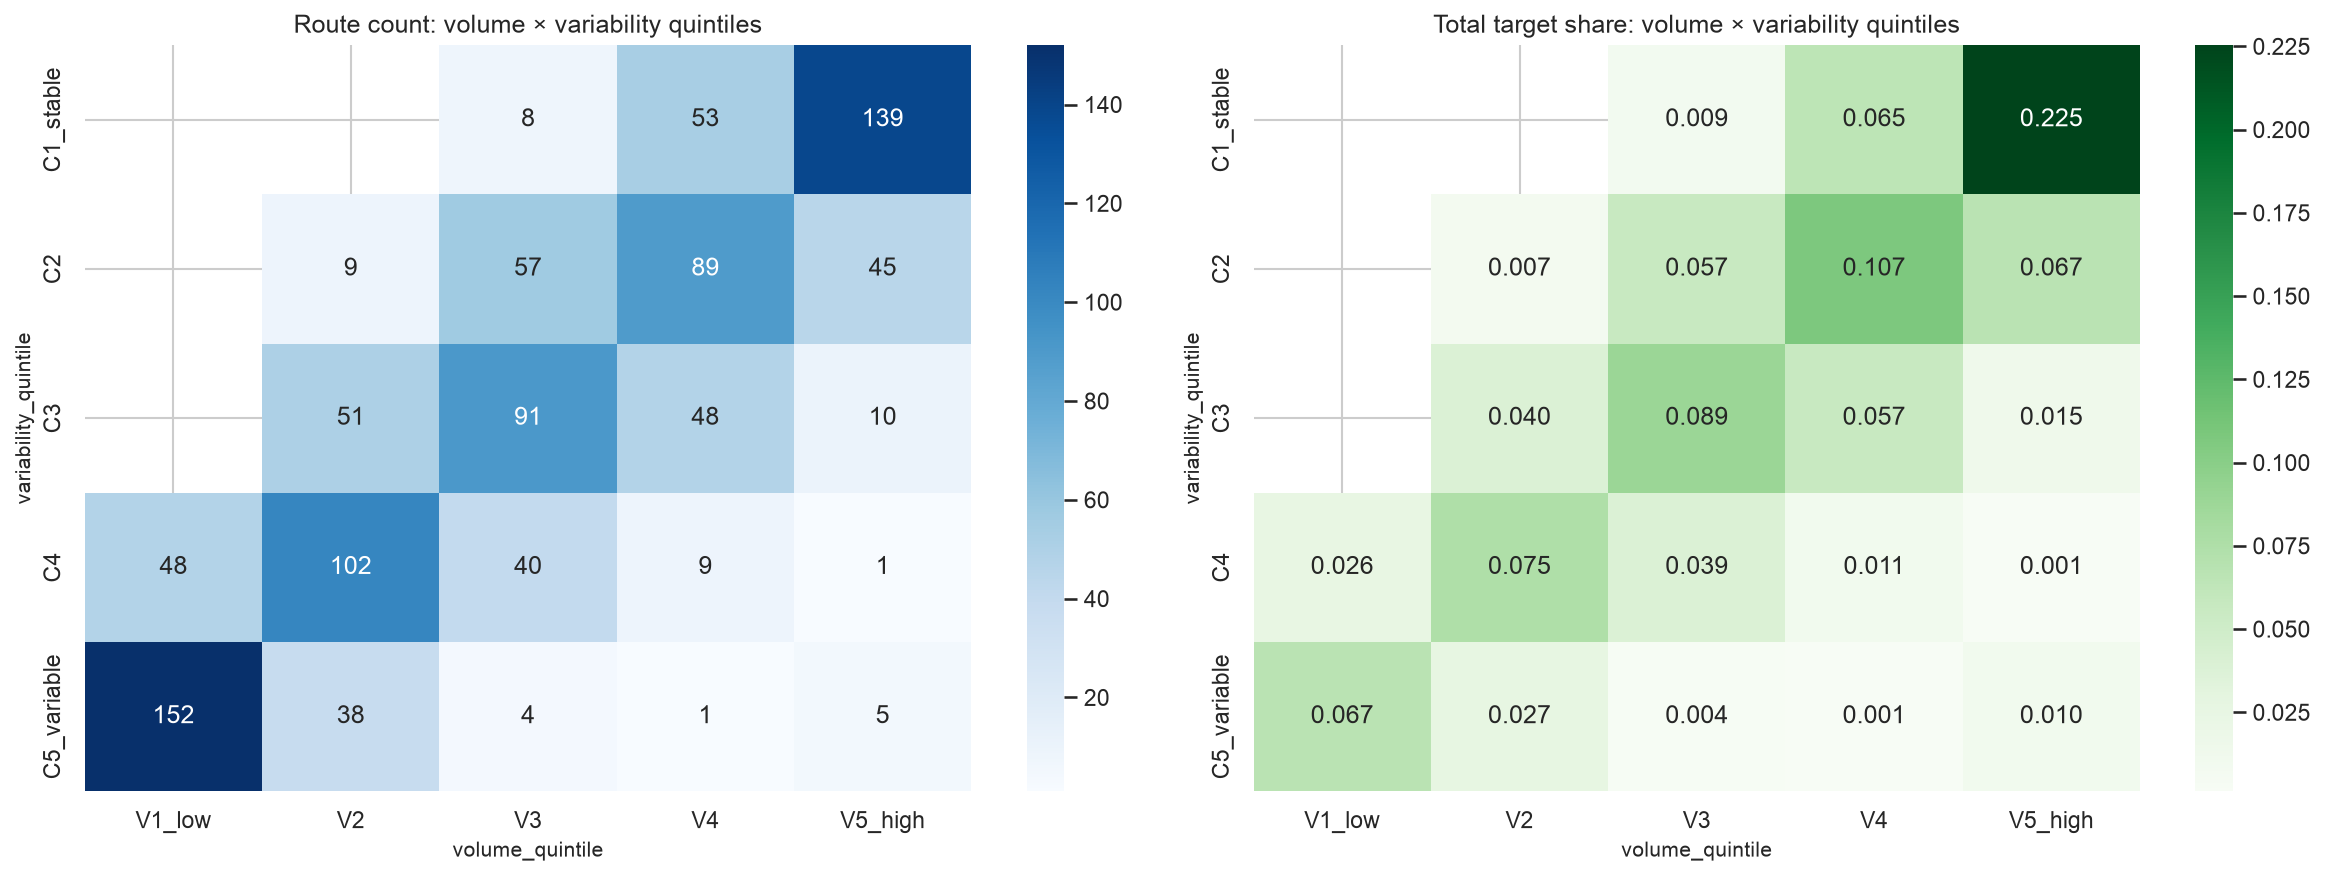

In [19]:
display(deep_tables['segment_summary'])
display(Image(filename=str(PLOT_DIR / '13_route_segmentations.png')))

## 19. Проверенные факты углублённого прохода

Таблица ниже программно извлекает значения; она не принимает модельных решений.

In [20]:
zero = deep_tables['zero_overview'].set_index('metric')['value']
stability = deep_tables['stability_overview'].set_index('metric')['value']
lead_lag = deep_tables['status_lead_lag']
best_centered = lead_lag.loc[lead_lag['route_centered_pearson'].idxmax()]
deep_facts = pd.DataFrame({
    'fact': [
        'routes with zeros', 'maximum route zero percentage',
        'maximum consecutive zero run, steps', 'latest/earliest mean ratio',
        'route rank Spearman, earliest vs latest',
        'strongest route-centered status', 'its horizon, steps',
        'its route-centered correlation'
    ],
    'value': [
        zero['routes_with_at_least_one_zero'], zero['maximum_route_zero_pct'],
        zero['maximum_zero_run_steps'], stability['latest_vs_earliest_mean_ratio'],
        stability['route_mean_rank_spearman_earliest_latest'],
        best_centered['status'], best_centered['horizon_steps'],
        best_centered['route_centered_pearson']
    ]
})
display(deep_facts)

,fact,value
0,routes with zeros,865
1,maximum route zero percentage,23.2397
2,"maximum consecutive zero run, steps",135
3,latest/earliest mean ratio,1.2137
4,"route rank Spearman, earliest vs latest",0.896438
5,strongest route-centered status,status_3
6,"its horizon, steps",1
7,its route-centered correlation,0.392819


# Часть III. Исполняемый аудит двух исторических решений

Проверки ниже вызывают реальные feature-функции на маленьких синтетических временных рядах. Они не обучают модели, не используют скрытые test labels и не изменяют исторические репозитории.

In [21]:
solution_audit = run_solution_audit()
solution_tables = solution_audit['tables']
print(solution_audit['metadata'])

{'historical_source_files_modified': False, 'models_trained': False, 'hidden_labels_used': False, 'failed_checks': 6, 'passed_checks': 0}


## 20. Какие исходники проверялись

Хэши позволяют повторить аудит именно на этих версиях файлов.

In [22]:
display(solution_tables['source_manifest'])

,file,exists,bytes,sha256
0,./solution.py,True,42305,fce56d3a583a9b1aa3bd4e459ccaeae35b744b531660d2...
1,/src/features.py,True,5227,8ca33fa2e7ccd4af5031b0603ebd54b6a10e83d96d49e9...
2,/src/train_impro...,True,5637,f188d587caedcc18c2fb9b23dea0f1bed2eff56ef555cf...
3,/src/predict_imp...,True,2984,c4acbbfc83d4ed74976fd62ec9508c899066f0ed604135...
4,/src/train_advan...,True,5227,5b1a118b11b9471a2b9ea2acde5770637c9aaeb7bdc60d...
5,/src/predict_adv...,True,2037,dbcf26d3ec10a7cab7423acd66fc9feb0b68ceba780797...
6,/src/train_per_r...,True,6477,574192abed61ebbd6f77a3906975aaa14f7b8f1ea721a6...
7,/src/predict_per...,True,3378,72425691859ef25e8690c2f1ba5f15682df8703b5435f2...


## 21. Проверки leakage, entity isolation и train/test parity

`P0` означает, что проверка способна сделать validation несопоставимой с реальным inference или полностью нарушить масштаб прогноза. `P1` означает существенный риск, влияние которого зависит от конкретного места вызова.

,solution,finding_id,severity,category,check,observed,expected,risk,file,line,passed,status
0,wb_second_solution,WB-ROLLING-CURRENT-TARGET,P0,target_leakage,Does first rolling feature contain the current...,10.0,NaN/absent until past target exists,Validation can become unrealistically strong b...,/src/features.py,68,False,FAIL
1,wb_second_solution,WB-FULL-HISTORY-ROUTE-AGG,P0,temporal_leakage,Does a future target change the route feature ...,34.0,1.0,Computing aggregates before temporal split lea...,/src/train_impro...,12,False,FAIL
2,wb_second_solution,WB-TRAIN-TEST-FEATURE-PARITY,P0,training_serving_skew,Are all model features produced by the test pi...,"51 missing: ['current_wh_max', 'current_wh_min...",0 missing features,Inference fills absent trained features with z...,/src/features.py,95,False,FAIL
3,current_hackathon_solution,CURRENT-CROSS-ROUTE-ROLLING,P0,entity_contamination,Does the first row of route 1 inherit rolling ...,20.0,NaN at a route boundary with min_lag=1,Features for one route can contain target hist...,./solution.py,128,False,FAIL
4,current_hackathon_solution,CURRENT-RANDOM-TARGET-ENCODING,P1,temporal_leakage,Does changing only future labels alter the ear...,before=10.812; after=10010.812,earliest-row feature unchanged by future labels,Random K-fold target encoding violates chronol...,./solution.py,164,False,FAIL
5,current_hackathon_solution,CURRENT-FULL-HISTORY-ROUTE-AGG,P1,temporal_leakage,Does a future target alter an aggregate featur...,34.0,1.0,Safe only when train_df is strictly limited to...,./solution.py,139,False,FAIL


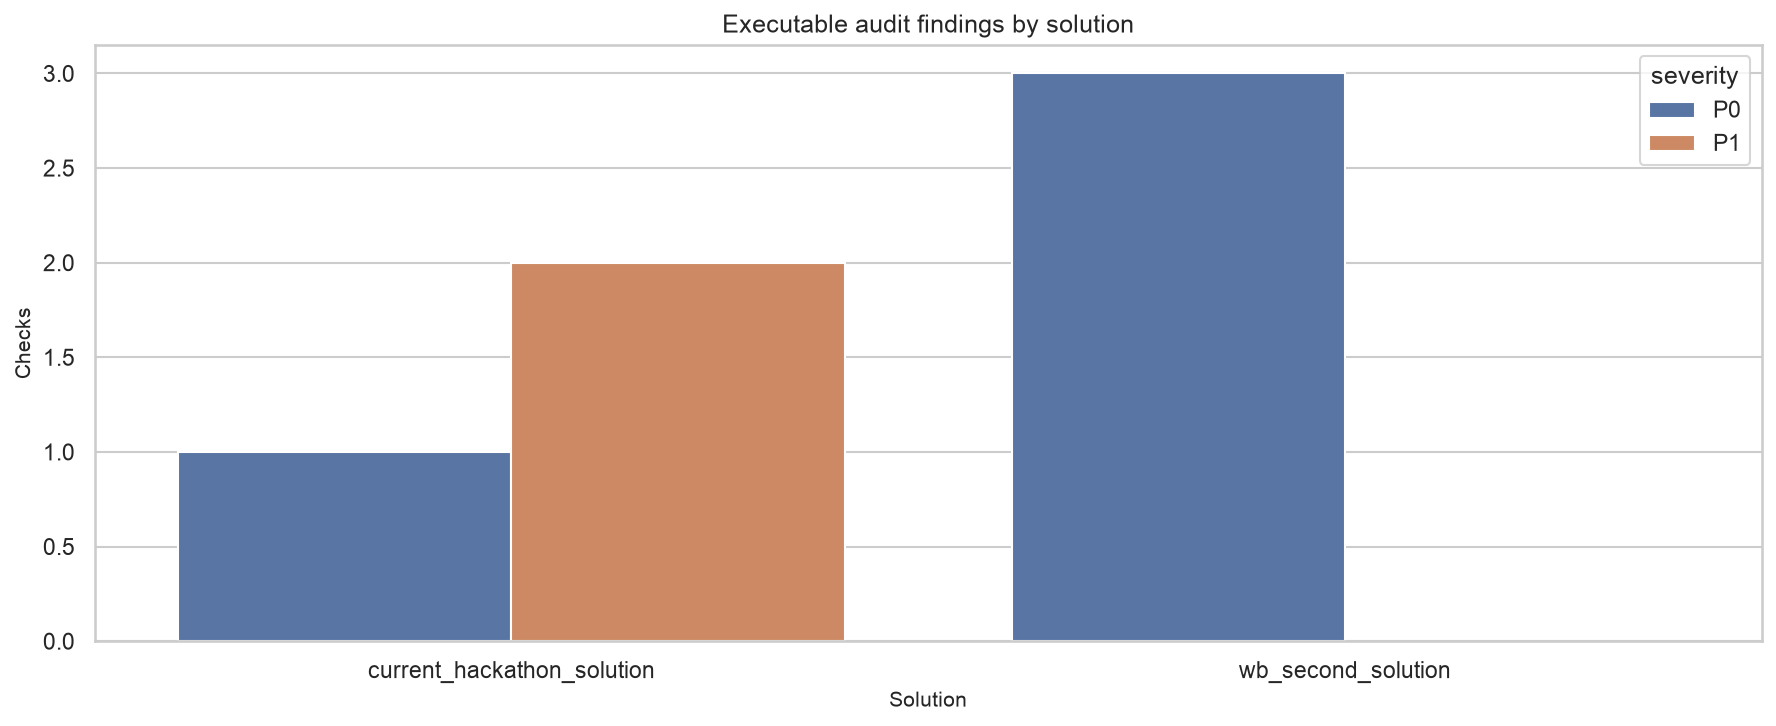

In [23]:
display(solution_tables['findings'])
display(Image(filename=str(AUDIT_PLOT_DIR / '01_executable_findings.png')))

## 22. Численные контрпримеры

Эти значения являются непосредственными результатами функций проектов. Например, rolling первого наблюдения не должен знать его собственный target, а первый ряд нового маршрута не должен получать историю предыдущего маршрута.

In [24]:
display(Markdown('**Второе решение `<comparison_repo>`**'))
display(solution_tables['wb_demonstration'])
display(Markdown('**Текущее решение `wildberries-hackathon/solution.py`**'))
display(solution_tables['current_demonstration'])

**Второе решение `<comparison_repo>`**

,check,value
0,WB rolling mean at first row,10
1,WB early-row route mean using full data,34
2,WB early-row route mean using train-only data,1
3,WB missing trained features in test pipeline,51


**Текущее решение `wildberries-hackathon/solution.py`**

,check,value
0,Current solution route-boundary roll_mean_6,20
1,Current earliest target encoding before future...,10.8125
2,Current earliest target encoding after future ...,"10,010.8"
3,Current early-row route mean using future,34
4,Current early-row route mean using past only,1


## 23. Структура и масштаб сохранённых сабмитов

Без скрытых labels нельзя измерить качество, но можно проверить число строк, ID, пропуски, отрицательные значения и аномальный масштаб. Точки около нуля на графике показывают версии, сломанные ещё до оценки leaderboard.

,solution,file,rows,prediction_column,id_unique,missing_predictions,negative_predictions,minimum,mean,median,maximum,std,status
0,current_hackathon_solution,submission_solo.csv,8000,y_pred,True,0,0,129.609,"291,758","282,624",2.07099e+06,"128,088",OK
11,wb_second_solution,submission_per_route.csv,8000,y_pred,True,0,0,"2,810.87","15,747","20,289.4","23,893.3","8,196.8",OK
13,wb_second_solution,submission_solo.csv,8000,y_pred,True,0,0,"1,895.23","267,369","257,260",2.19534e+06,"126,084",OK
23,wb_second_solution,submission_v2.csv,8000,y_pred,True,0,0,0,"277,470","252,810","920,430","166,977",OK
32,wb_second_solution,submission_v3_lgb_xgb.csv,8000,y_pred,True,0,0,"5,199.03","5,199.03","5,199.03","5,199.03",0,OK
33,wb_second_solution,submission_v4_final.csv,8000,y_pred,True,0,0,"5,109.81","7,192.48","7,455.58","7,998.49",705.468,OK


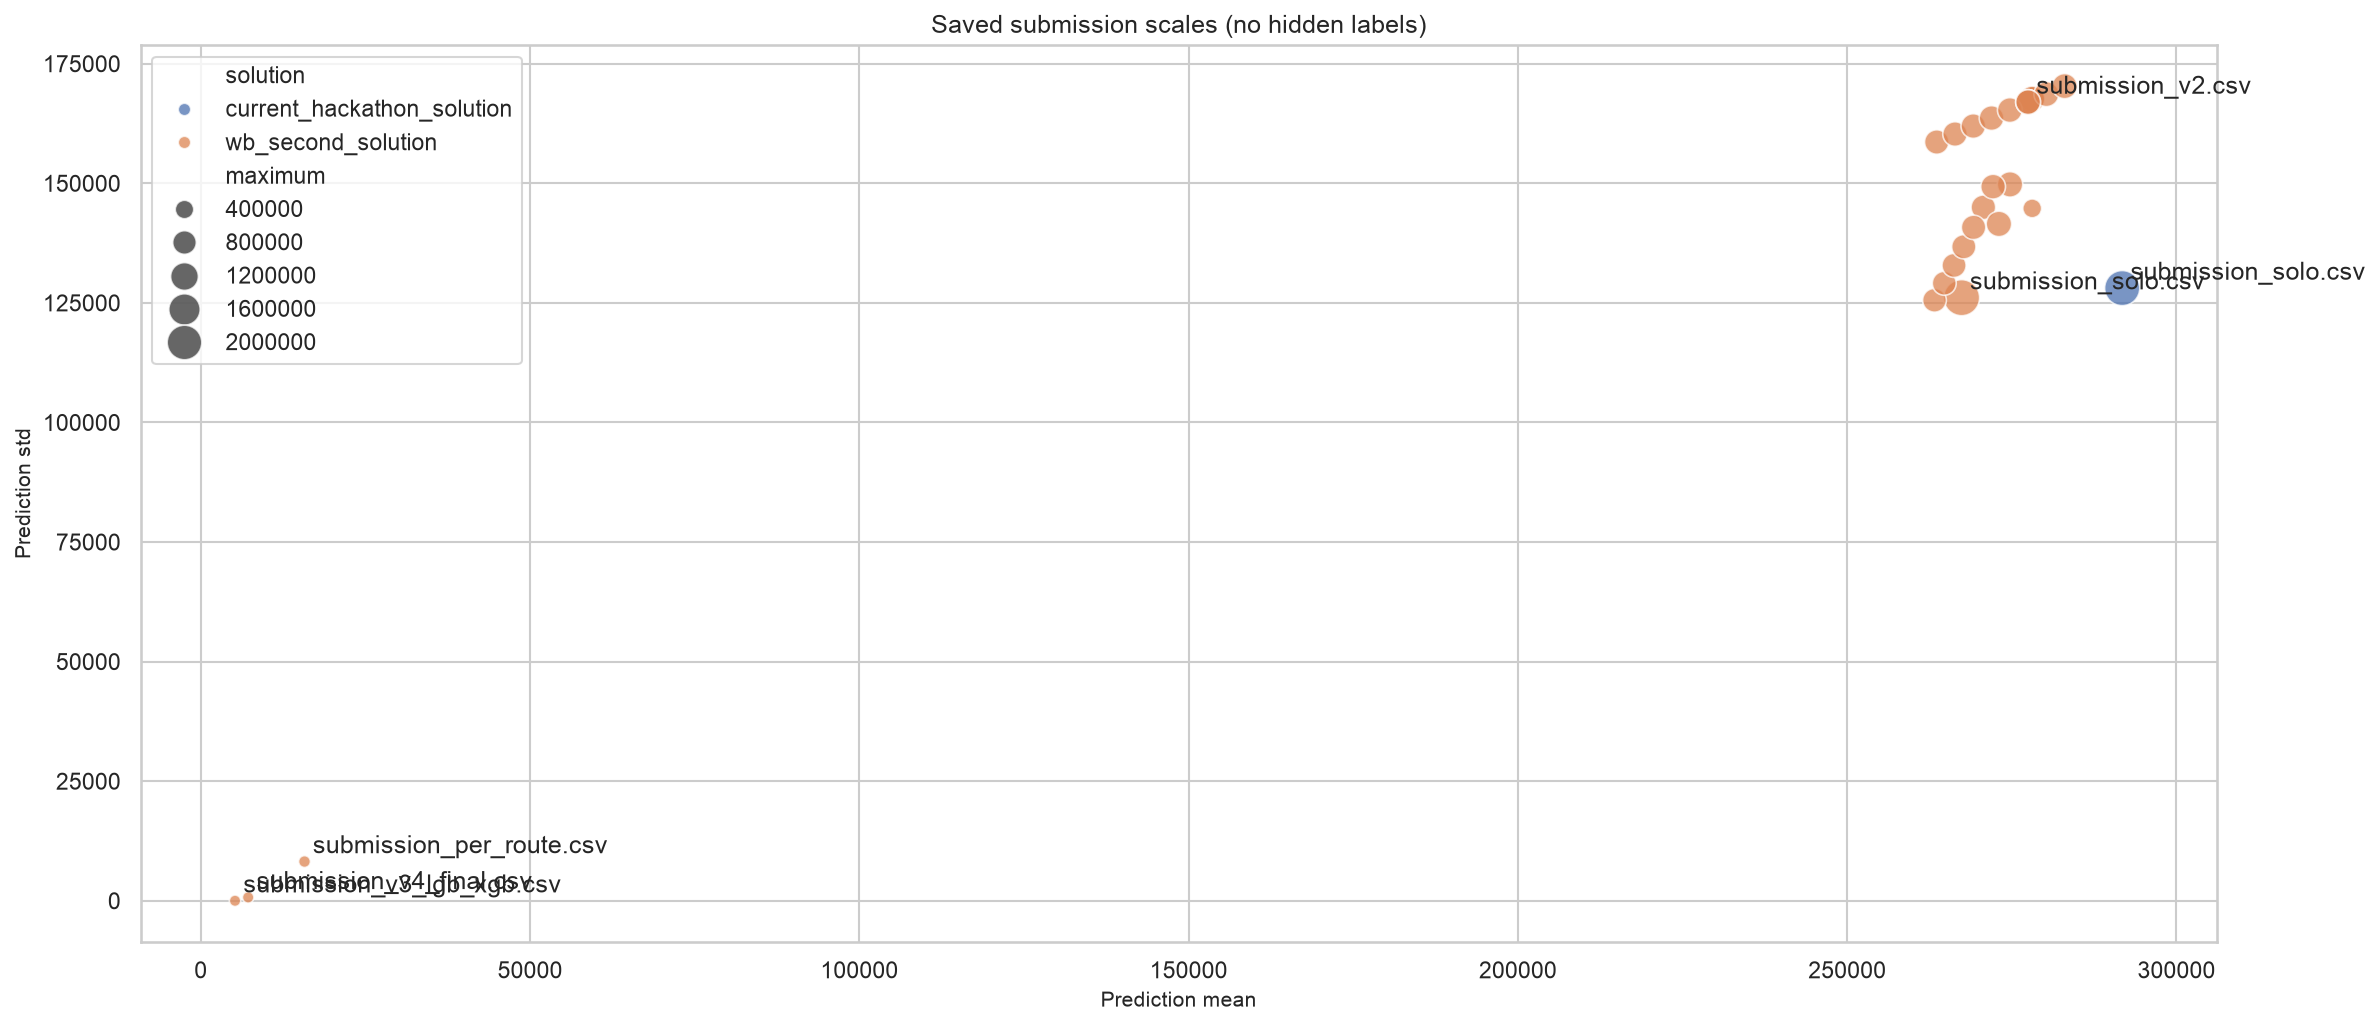

In [25]:
important_files = [
    'submission_solo.csv', 'submission_v2.csv', 'submission_v3_lgb_xgb.csv',
    'submission_v4_final.csv', 'submission_per_route.csv',
]
display(solution_tables['submission_summary'].query('file in @important_files'))
display(Image(filename=str(AUDIT_PLOT_DIR / '02_submission_scales.png')))

## 24. Ограничения аудита решений

- Контрпримеры доказывают поведение функций, но не заменяют полный temporal backtest после исправлений.
- Проверка full-history aggregates является P0, если агрегаты считаются до внешнего validation split; внутри fold она может быть допустима.
- Submission scale выявляет поломку, но нормальный масштаб не доказывает качество.
- Веса ансамбля нельзя выбирать по public leaderboard или одному validation-окну.

# Часть IV. Принципиально разные направления следующего этапа

Ни одно направление пока не выбрано. Все варианты будут сравниваться с одинаковыми test-like temporal folds и простыми baseline.

| Код | Архитектура | Источник разнообразия | Основной плюс | Основной риск | Стоимость | Защита |
|---|---|---|---|---|---|---|
| A | Прозрачные baseline: seasonal naive + median/route profile + один global booster | Разные простые предположения | Максимально понятная проверочная точка | Ограниченный потолок | Низкая | Простая |
| B | Heterogeneous tabular ensemble: LightGBM + XGBoost + CatBoost, direct по горизонтам | Разные алгоритмы и loss | Соответствует опыту пользователя, сильный табличный стек | Ошибки могут быть сильно коррелированы | Средняя | Средняя |
| C | Forecast-strategy ensemble: seasonal naive + direct + recursive + snapshot-status | Разная динамика прогноза | Диверсификация не только seed/алгоритмом | Сложнее обеспечить одинаковый контракт признаков | Средняя/высокая | Средняя |
| D | Hierarchical mixture of experts: global fallback + эксперты volume × variability | Разные группы маршрутов | Может учитывать сильную неоднородность | Нестабильные малые сегменты и жёсткие границы | Высокая | Сложная |
| E | Hybrid deep ensemble: N-HiTS/PatchTST + boosting | Нейросеть и деревья видят разные паттерны | Максимальное архитектурное разнообразие, доступна RTX 5090 | Время, tuning и сложность честной защиты | Очень высокая | Сложная |

Для любого ансамбля обязательны: OOF-предсказания на одинаковых folds, метрики каждой модели, корреляции ошибок, ablation ансамбля, веса без test labels и global fallback.